In [93]:
from __future__ import annotations
import itertools, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path(r"C:\Users\firep\Downloads\simple_analysis_script\timing_results_v2")
PLOT_DIR = RESULTS_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CHANNELS = ("C1", "C2", "C3", "C4")
COLORS = {"C1": "#1f77b4", "C2": "#d62728", "C3": "#2ca02c", "C4": "#9467bd"}
SAVE = True
DPI = 160

def load(name):
    path = RESULTS_DIR / name
    return pd.read_csv(path) if path.is_file() else pd.DataFrame()

def finish(figure, name):
    figure.tight_layout()
    if SAVE:
        figure.savefig(PLOT_DIR / f"{name}.png", dpi=DPI)
    plt.show()

features = load("waveform_features.csv")
physical = features[features["trace_role"] == "physical"].copy() if not features.empty else pd.DataFrame()
valid = physical[physical["timing_valid"].astype(bool)] if not physical.empty else pd.DataFrame()
channel_summary = load("physical_channel_summary.csv")
rejections = load("rejection_reasons.csv")
drift = load("background_drift.csv")
raw_background = load("raw_pretrigger_background.csv")
analytic = load("analytic_accidental_rates.csv")
mixing = load("accidental_fourfold_mixing.csv")
pair_mixing = load("accidental_pairwise_mixing.csv")
noise_hist = load("background_noise_histogram.csv")
noise_fit = load("background_noise_gaussian_fit.csv")
delta_hist = load("pairwise_delta_t_histogram.csv")
delta_fit = load("pairwise_gaussian_fit.csv")
pe_hist = load("background_pulse_amplitude_histogram.csv")
staircase = load("background_rate_vs_threshold.csv")
pe_estimate = load("background_pe_estimate.csv")
poisson = load("background_poisson_test.csv")
poisson_dist = load("background_poisson_distribution.csv")
prediction = load("timing_noise_prediction.csv")
predicted_vs_measured = load("timing_predicted_vs_measured.csv")
pairwise = load("coincidence_pairwise_deltas.csv")
pair_summary = load("coincidence_pairwise_summary.csv")
resolution = load("channel_resolution_decomposition.csv")
offsets = load("channel_offsets.csv")
coincidence = load("coincidence_summary.csv")
event_status = load("coincidence_event_status.csv")

# added for the extended noise / consistency / correlation study
triplet_estimates = load("channel_resolution_triplet_estimates.csv")
pair_sigma_compat = load("timing_pair_sigma_compatibility.csv")
delta_t_corr = load("pairwise_delta_t_correlation.csv")
noise_sigma_summary = load("noise_sigma_summary.csv")
noise_sigma_compat = load("noise_sigma_compatibility.csv")
channel_noise_corr = load("channel_noise_correlation.csv")

raw_pairs = pair_summary[pair_summary["timing_column"] == "delta_t_ns"] if not pair_summary.empty else pd.DataFrame()
walk_pairs = pair_summary[pair_summary["timing_column"] == "delta_t_corrected_ns"] if not pair_summary.empty else pd.DataFrame()
devices = sorted(physical["device"].dropna().unique()) if not physical.empty else []
runs = sorted(pairwise["coincidence_run"].unique()) if not pairwise.empty else []

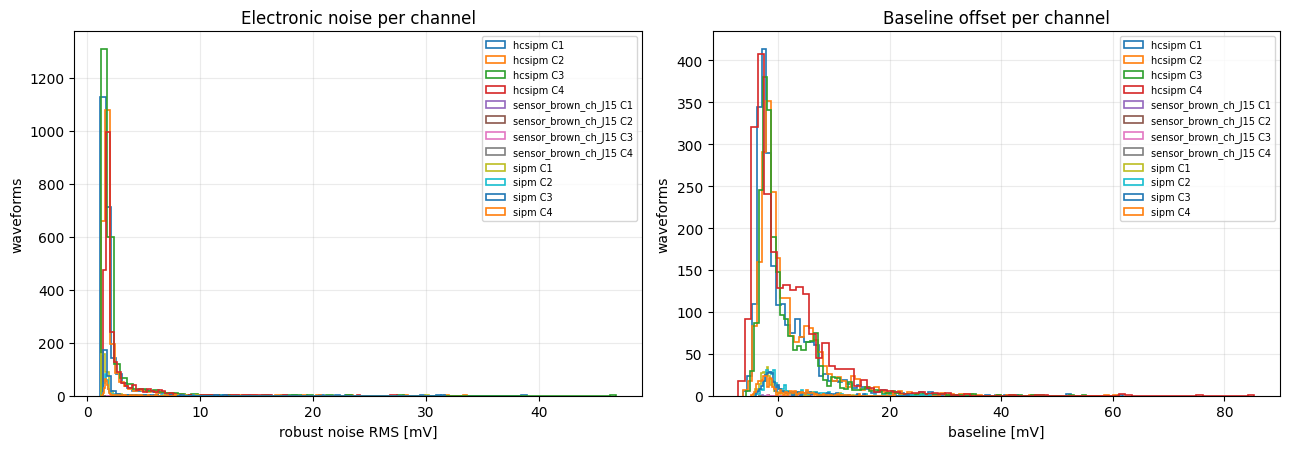

In [94]:
# BACKGROUND 1: noise level and baseline position per channel
if not physical.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for (device, channel), group in physical.groupby(["device", "channel"]):
        axes[0].hist(pd.to_numeric(group["noise_rms_robust_v"], errors="coerce").dropna() * 1e3,
                     bins=80, histtype="step", lw=1.2, label=f"{device} {channel}")
        axes[1].hist(pd.to_numeric(group["baseline_v"], errors="coerce").dropna() * 1e3,
                     bins=80, histtype="step", lw=1.2, label=f"{device} {channel}")
    axes[0].set_xlabel("robust noise RMS [mV]")
    axes[1].set_xlabel("baseline [mV]")
    for axis in axes:
        axis.set_ylabel("waveforms")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=7)
    axes[0].set_title("Electronic noise per channel")
    axes[1].set_title("Baseline offset per channel")
    finish(figure, "bg01_noise_baseline")

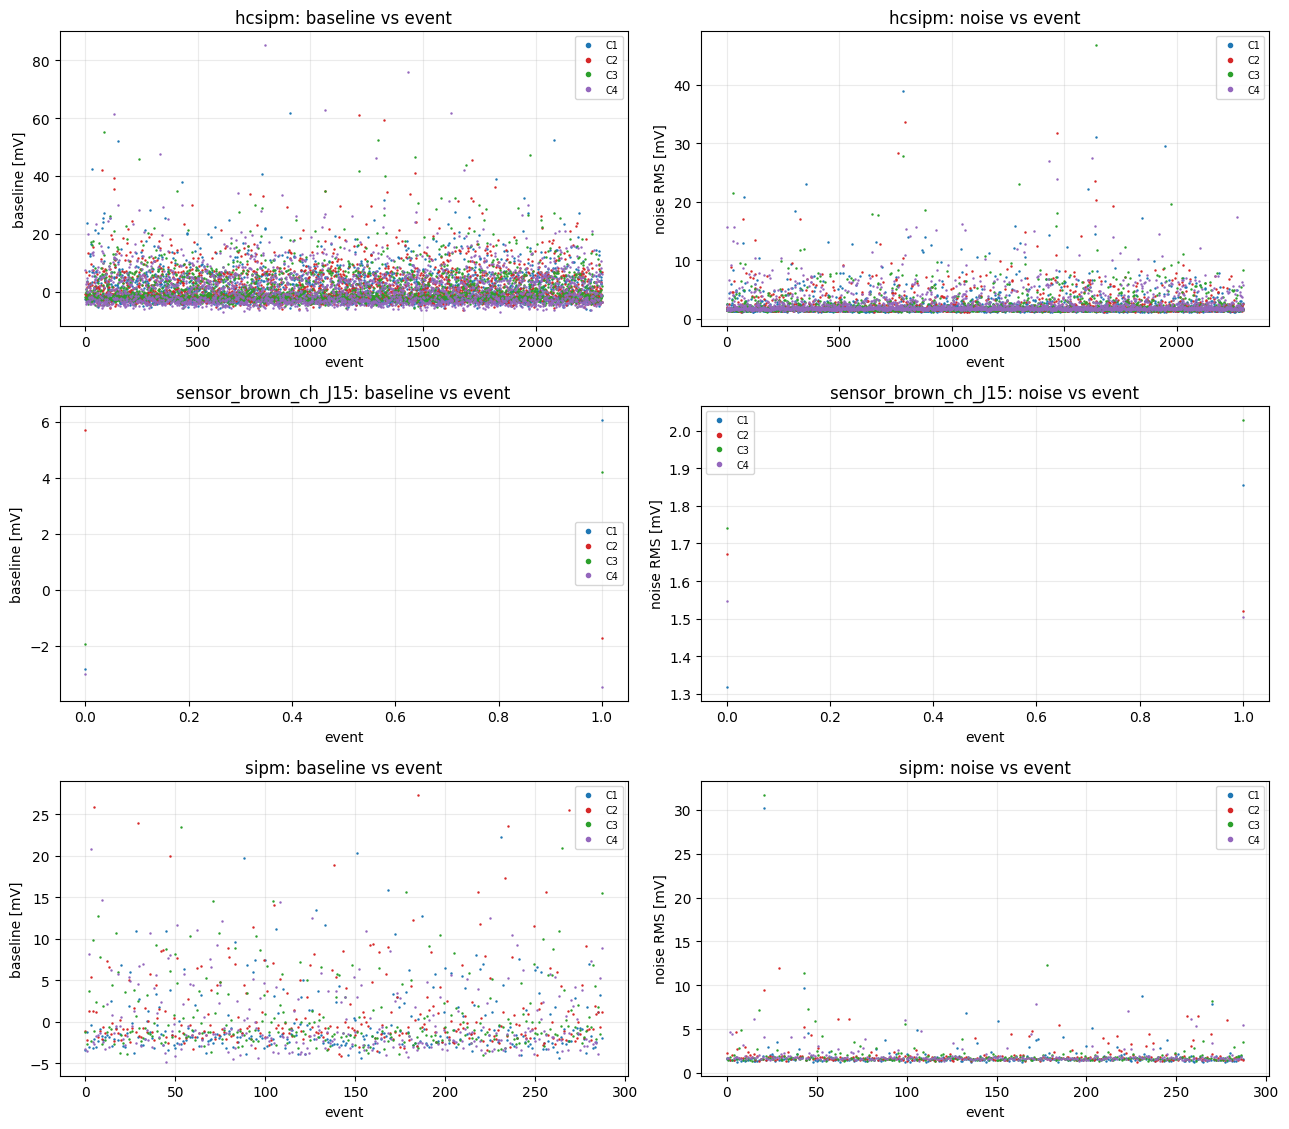

In [95]:
# BACKGROUND 2: stability across the run
if not physical.empty:
    figure, axes = plt.subplots(len(devices), 2, figsize=(13, 3.8 * max(1, len(devices))), squeeze=False)
    for row, device in enumerate(devices):
        subset = physical[physical["device"] == device]
        for channel, group in subset.groupby("channel"):
            ordered = group.sort_values("event")
            color = COLORS.get(channel)
            axes[row, 0].plot(ordered["event"], ordered["baseline_v"] * 1e3, ".", ms=1.5, color=color, label=channel)
            axes[row, 1].plot(ordered["event"], ordered["noise_rms_robust_v"] * 1e3, ".", ms=1.5, color=color, label=channel)
        axes[row, 0].set_ylabel("baseline [mV]")
        axes[row, 1].set_ylabel("noise RMS [mV]")
        axes[row, 0].set_title(f"{device}: baseline vs event")
        axes[row, 1].set_title(f"{device}: noise vs event")
        for axis in axes[row]:
            axis.set_xlabel("event")
            axis.grid(alpha=0.25)
            axis.legend(fontsize=7, markerscale=4)
    finish(figure, "bg02_stability")

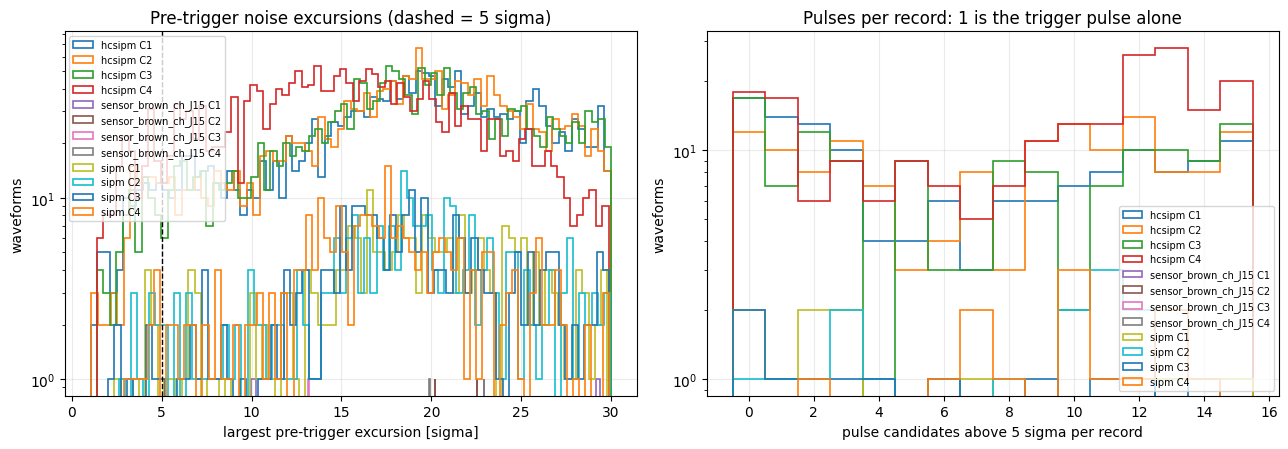

In [96]:
# BACKGROUND 3: pre-trigger excursions, the direct handle on uncorrelated pulses
if not physical.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for (device, channel), group in physical.groupby(["device", "channel"]):
        v = pd.to_numeric(group["pretrigger_max_sigma"], errors="coerce").dropna()
        axes[0].hist(v[v < 30], bins=80, histtype="step", lw=1.2, label=f"{device} {channel}")
        counts = pd.to_numeric(group["n_pulse_candidates"], errors="coerce").dropna()
        edges = np.arange(-0.5, min(15, counts.max() if counts.size else 1) + 1.5)
        axes[1].hist(counts, bins=edges, histtype="step", lw=1.2, label=f"{device} {channel}")
    axes[0].axvline(5, color="black", ls="--", lw=1)
    axes[0].set_xlabel("largest pre-trigger excursion [sigma]")
    axes[0].set_ylabel("waveforms")
    axes[0].set_title("Pre-trigger noise excursions (dashed = 5 sigma)")
    axes[0].set_yscale("log")
    axes[1].set_xlabel("pulse candidates above 5 sigma per record")
    axes[1].set_ylabel("waveforms")
    axes[1].set_title("Pulses per record: 1 is the trigger pulse alone")
    axes[1].set_yscale("log")
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend(fontsize=7)
    finish(figure, "bg03_pretrigger_excursions")

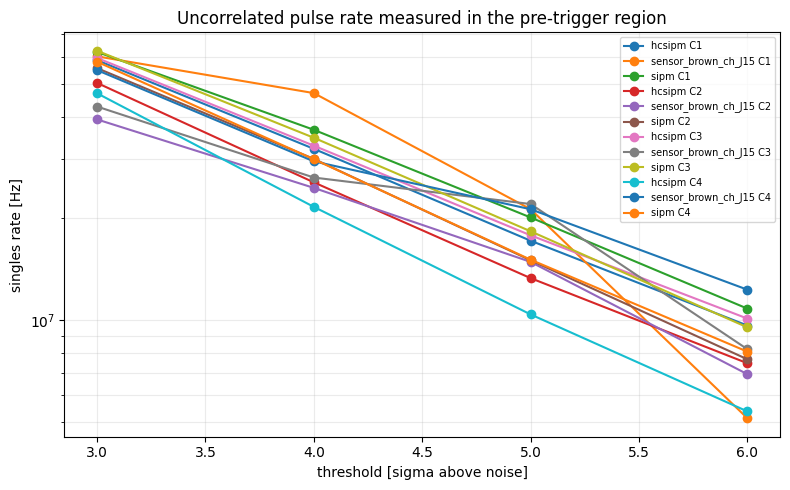

In [97]:
# BACKGROUND 4: measured singles rate vs threshold
if not raw_background.empty:
    sigmas = sorted(float(c.split("_")[-1].replace("sigma", ""))
                    for c in raw_background.columns if c.startswith("rate_hz_"))
    figure, axis = plt.subplots(figsize=(8, 5))
    for _, row in raw_background.iterrows():
        rates = [row[f"rate_hz_{s:g}sigma"] for s in sigmas]
        axis.semilogy(sigmas, rates, "o-", label=f"{row['device']} {row['channel']}")
    axis.set_xlabel("threshold [sigma above noise]")
    axis.set_ylabel("singles rate [Hz]")
    axis.set_title("Uncorrelated pulse rate measured in the pre-trigger region")
    axis.grid(alpha=0.25, which="both")
    axis.legend(fontsize=7)
    finish(figure, "bg04_singles_rate")

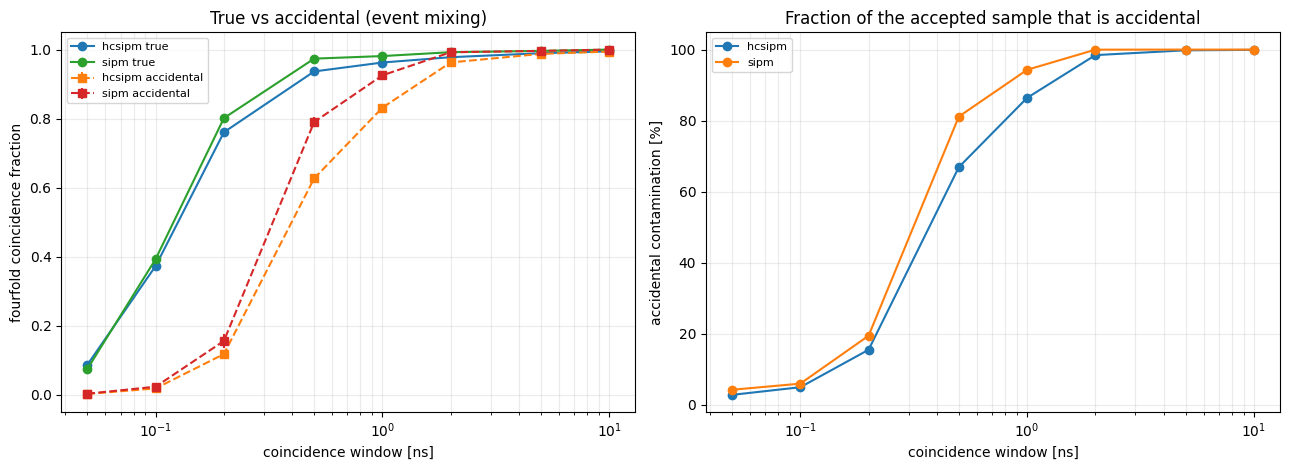

In [98]:
# BACKGROUND 5: accidental vs true coincidence rate
if not mixing.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for run, group in mixing.groupby("coincidence_run"):
        ordered = group.sort_values("coincidence_window_ns")
        axes[0].plot(ordered["coincidence_window_ns"], ordered["true_coincidence_fraction"], "o-", label=f"{run} true")
        axes[0].errorbar(ordered["coincidence_window_ns"], ordered["accidental_fraction_mean"],
                         yerr=ordered["accidental_fraction_std"], fmt="s--", label=f"{run} accidental")
        axes[1].plot(ordered["coincidence_window_ns"], ordered["accidental_contamination"] * 100, "o-", label=run)
    axes[0].set_ylabel("fourfold coincidence fraction")
    axes[0].set_title("True vs accidental (event mixing)")
    axes[1].set_ylabel("accidental contamination [%]")
    axes[1].set_title("Fraction of the accepted sample that is accidental")
    for axis in axes:
        axis.set_xscale("log")
        axis.set_xlabel("coincidence window [ns]")
        axis.grid(alpha=0.25, which="both")
        axis.legend(fontsize=8)
    finish(figure, "bg05_accidentals")

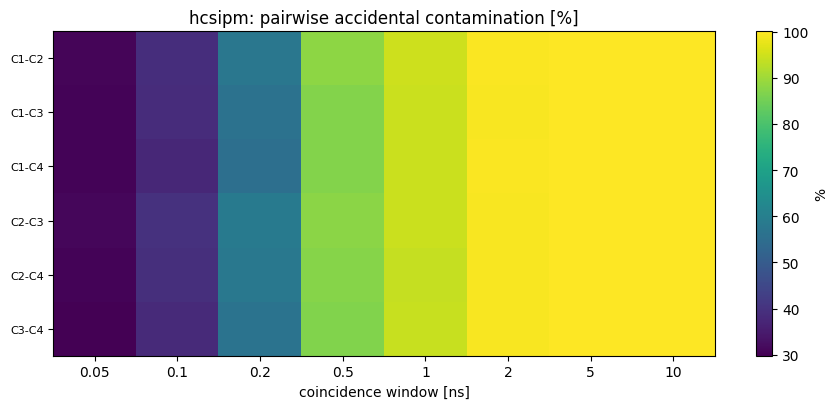

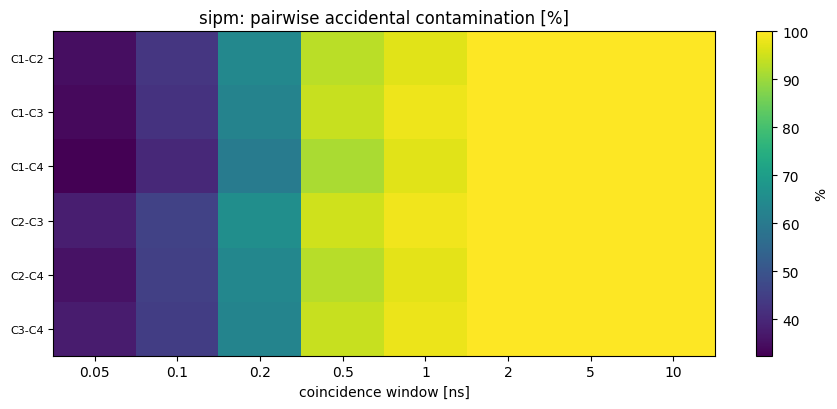

In [99]:
# BACKGROUND 6: pairwise accidental contamination heat map by window
if not pair_mixing.empty:
    for run in sorted(pair_mixing["coincidence_run"].unique()):
        subset = pair_mixing[pair_mixing["coincidence_run"] == run]
        table = subset.pivot_table(index=["channel_a", "channel_b"], columns="coincidence_window_ns",
                                   values="accidental_contamination")
        figure, axis = plt.subplots(figsize=(9, 4.2))
        image = axis.imshow(table.to_numpy() * 100, aspect="auto", cmap="viridis")
        axis.set_xticks(range(len(table.columns)))
        axis.set_xticklabels([f"{c:g}" for c in table.columns])
        axis.set_yticks(range(len(table.index)))
        axis.set_yticklabels([f"{a}-{b}" for a, b in table.index], fontsize=8)
        axis.set_xlabel("coincidence window [ns]")
        axis.set_title(f"{run}: pairwise accidental contamination [%]")
        figure.colorbar(image, ax=axis, label="%")
        finish(figure, f"bg06_pair_contamination_{run}")

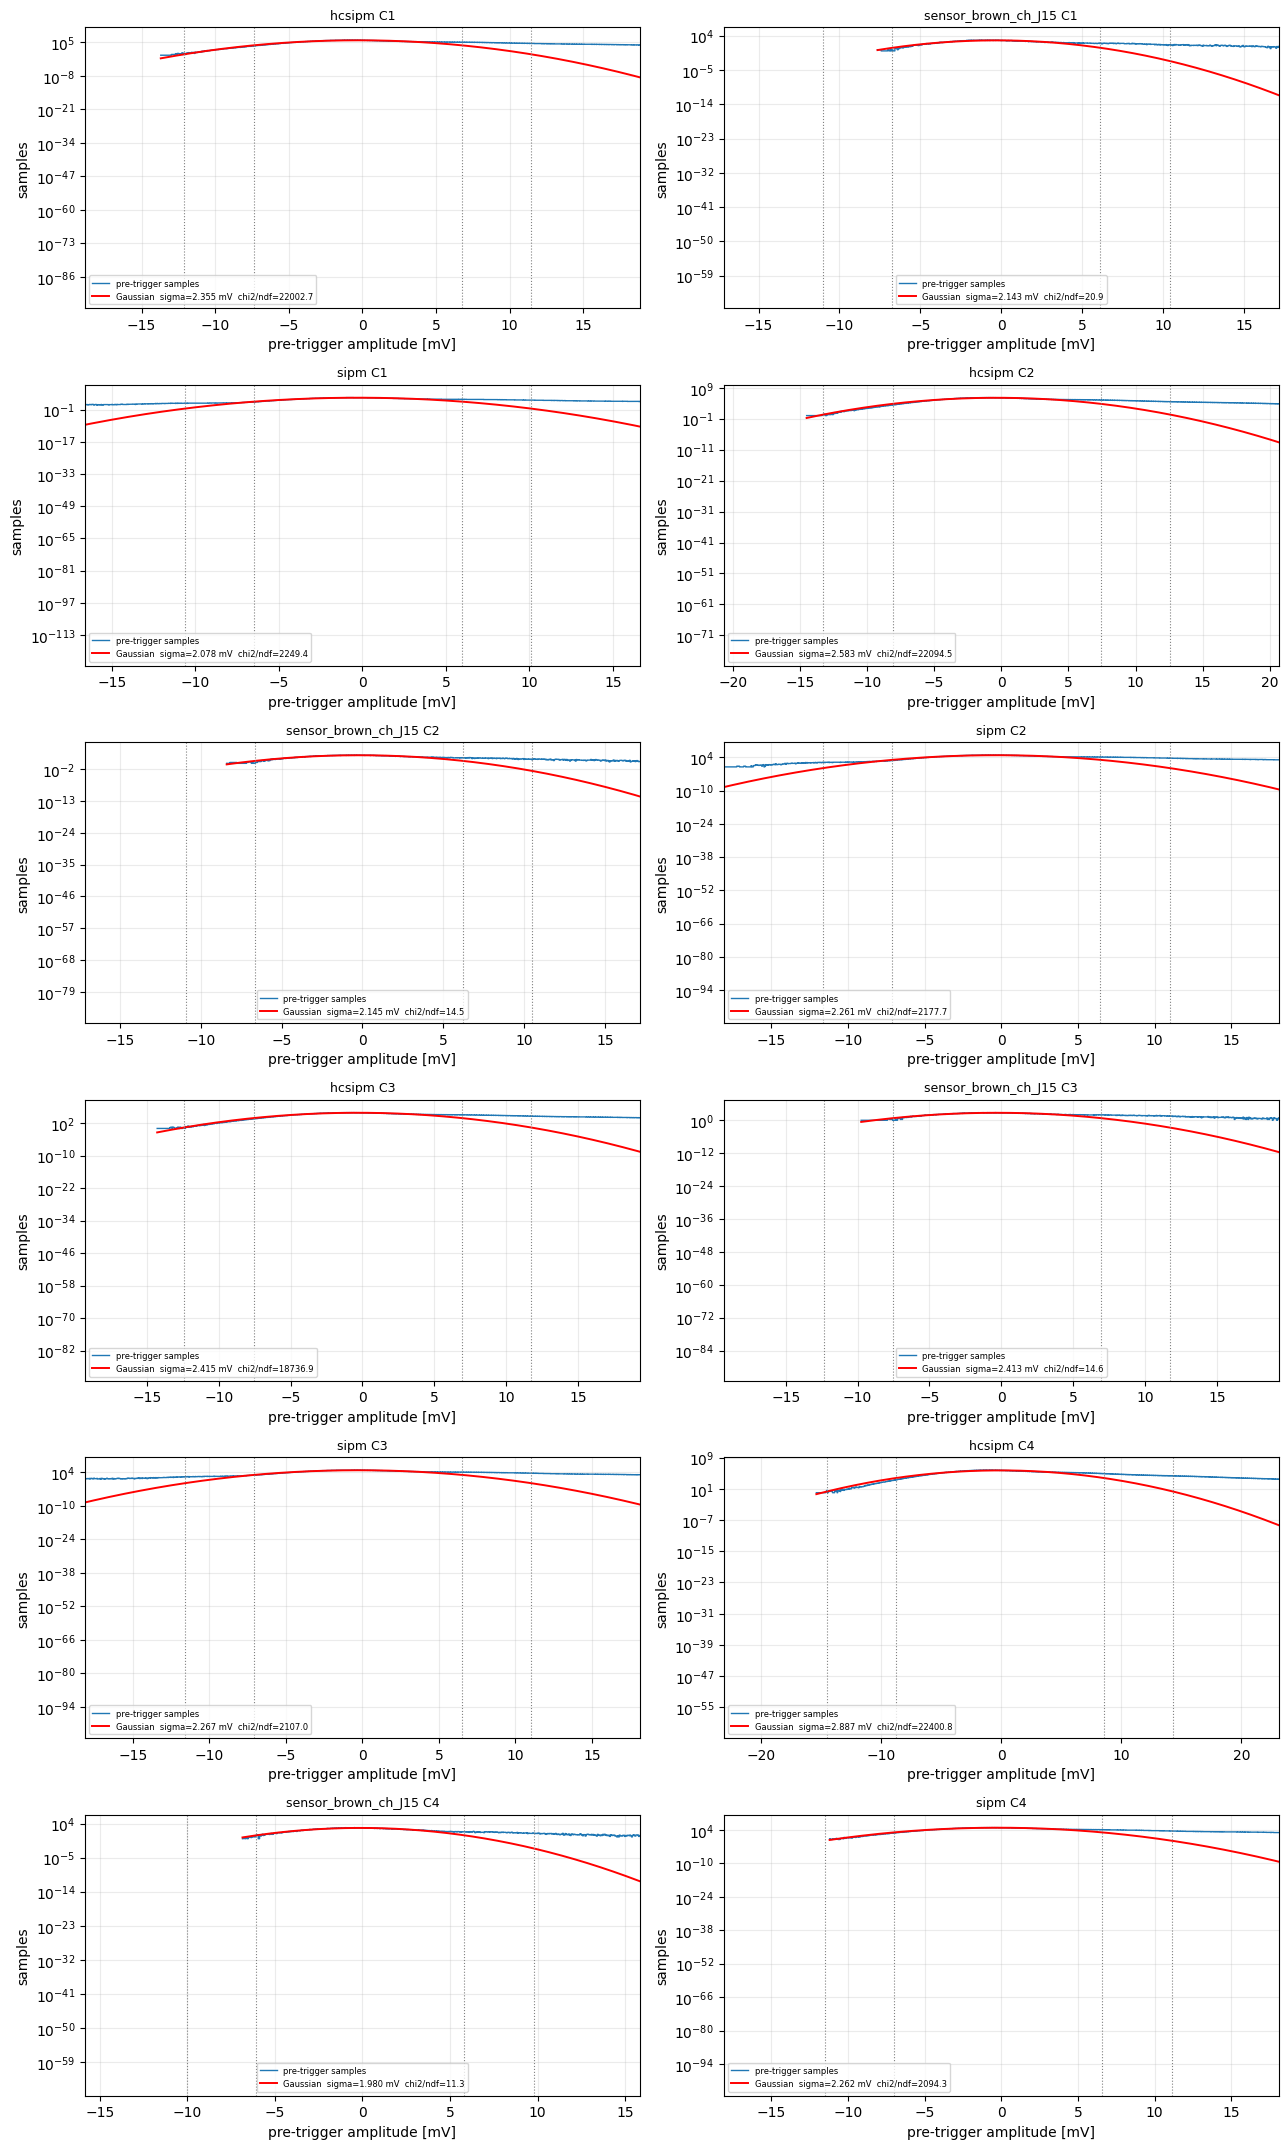

In [100]:
# BACKGROUND 7: Gaussian fit to the pre-trigger noise, log scale to expose tails
if not noise_hist.empty and not noise_fit.empty:
    keys = noise_fit[["device", "channel"]].drop_duplicates().values.tolist()
    ncols = 2
    nrows = int(np.ceil(len(keys) / ncols))
    figure, axes = plt.subplots(nrows, ncols, figsize=(13, 3.6 * nrows), squeeze=False)
    for axis, (device, channel) in zip(axes.ravel(), keys):
        h = noise_hist[(noise_hist["device"] == device) & (noise_hist["channel"] == channel)]
        f = noise_fit[(noise_fit["device"] == device) & (noise_fit["channel"] == channel)]
        if h.empty or f.empty:
            continue
        row = f.iloc[0]
        x = h["bin_center_v"].to_numpy(float) * 1e3
        axis.step(x, h["counts"].to_numpy(float), where="mid", lw=1.0, label="pre-trigger samples")
        if bool(row.get("fit_ok", False)):
            mu, sigma = row["fit_mu"] * 1e3, row["fit_sigma"] * 1e3
            grid = np.linspace(x.min(), x.max(), 800)
            axis.plot(grid, row["fit_amplitude"] * np.exp(-0.5 * ((grid - mu) / sigma) ** 2),
                      "r-", lw=1.4,
                      label=f"Gaussian  sigma={sigma:.3f} mV  chi2/ndf={row['fit_chi2_per_ndf']:.1f}")
            for k in (3, 5):
                axis.axvline(mu + k * sigma, color="grey", ls=":", lw=0.8)
                axis.axvline(mu - k * sigma, color="grey", ls=":", lw=0.8)
        axis.set_yscale("log")
        axis.set_xlim(-8 * row.get("fit_sigma", 0.002) * 1e3, 8 * row.get("fit_sigma", 0.002) * 1e3)
        axis.set_xlabel("pre-trigger amplitude [mV]")
        axis.set_ylabel("samples")
        axis.set_title(f"{device} {channel}", fontsize=9)
        axis.grid(alpha=0.25, which="both")
        axis.legend(fontsize=6)
    for axis in axes.ravel()[len(keys):]:
        axis.axis("off")
    finish(figure, "bg07_noise_gaussian_fit")

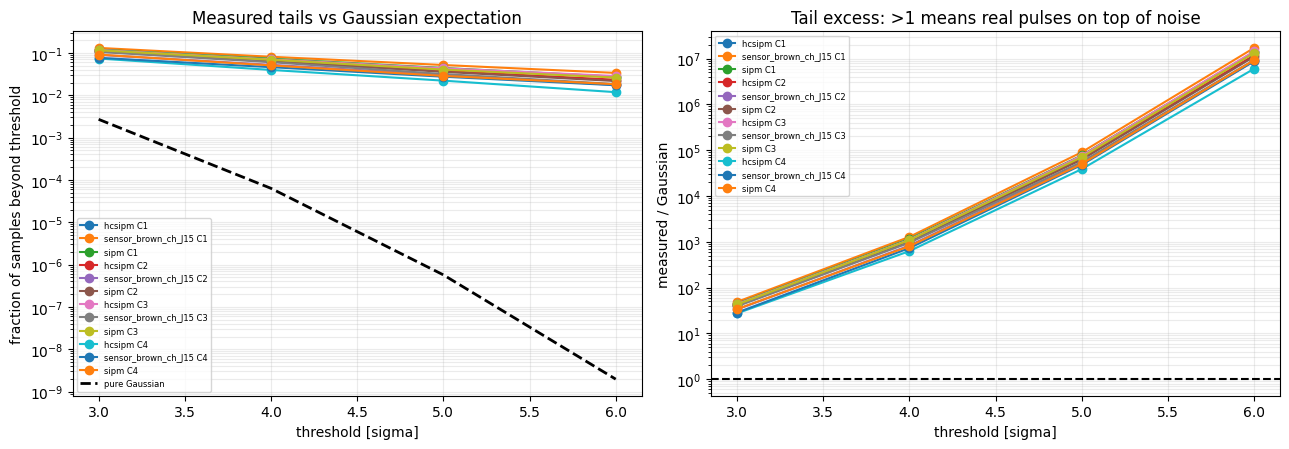

In [101]:
# BACKGROUND 8: is the noise actually Gaussian? measured tails vs prediction
if not noise_fit.empty:
    thresholds = [3.0, 4.0, 5.0, 6.0]
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for _, row in noise_fit.iterrows():
        label = f"{row['device']} {row['channel']}"
        measured = [row.get(f"tail_fraction_beyond_{k:g}sigma", np.nan) for k in thresholds]
        excess = [row.get(f"tail_excess_ratio_{k:g}sigma", np.nan) for k in thresholds]
        axes[0].semilogy(thresholds, measured, "o-", label=label)
        axes[1].semilogy(thresholds, excess, "o-", label=label)
    expected = [math.erfc(k / math.sqrt(2.0)) for k in thresholds]
    axes[0].semilogy(thresholds, expected, "k--", lw=2, label="pure Gaussian")
    axes[0].set_ylabel("fraction of samples beyond threshold")
    axes[0].set_title("Measured tails vs Gaussian expectation")
    axes[1].axhline(1.0, color="black", ls="--", lw=1.5)
    axes[1].set_ylabel("measured / Gaussian")
    axes[1].set_title("Tail excess: >1 means real pulses on top of noise")
    for axis in axes:
        axis.set_xlabel("threshold [sigma]")
        axis.grid(alpha=0.25, which="both")
        axis.legend(fontsize=6)
    finish(figure, "bg08_gaussian_tail_excess")

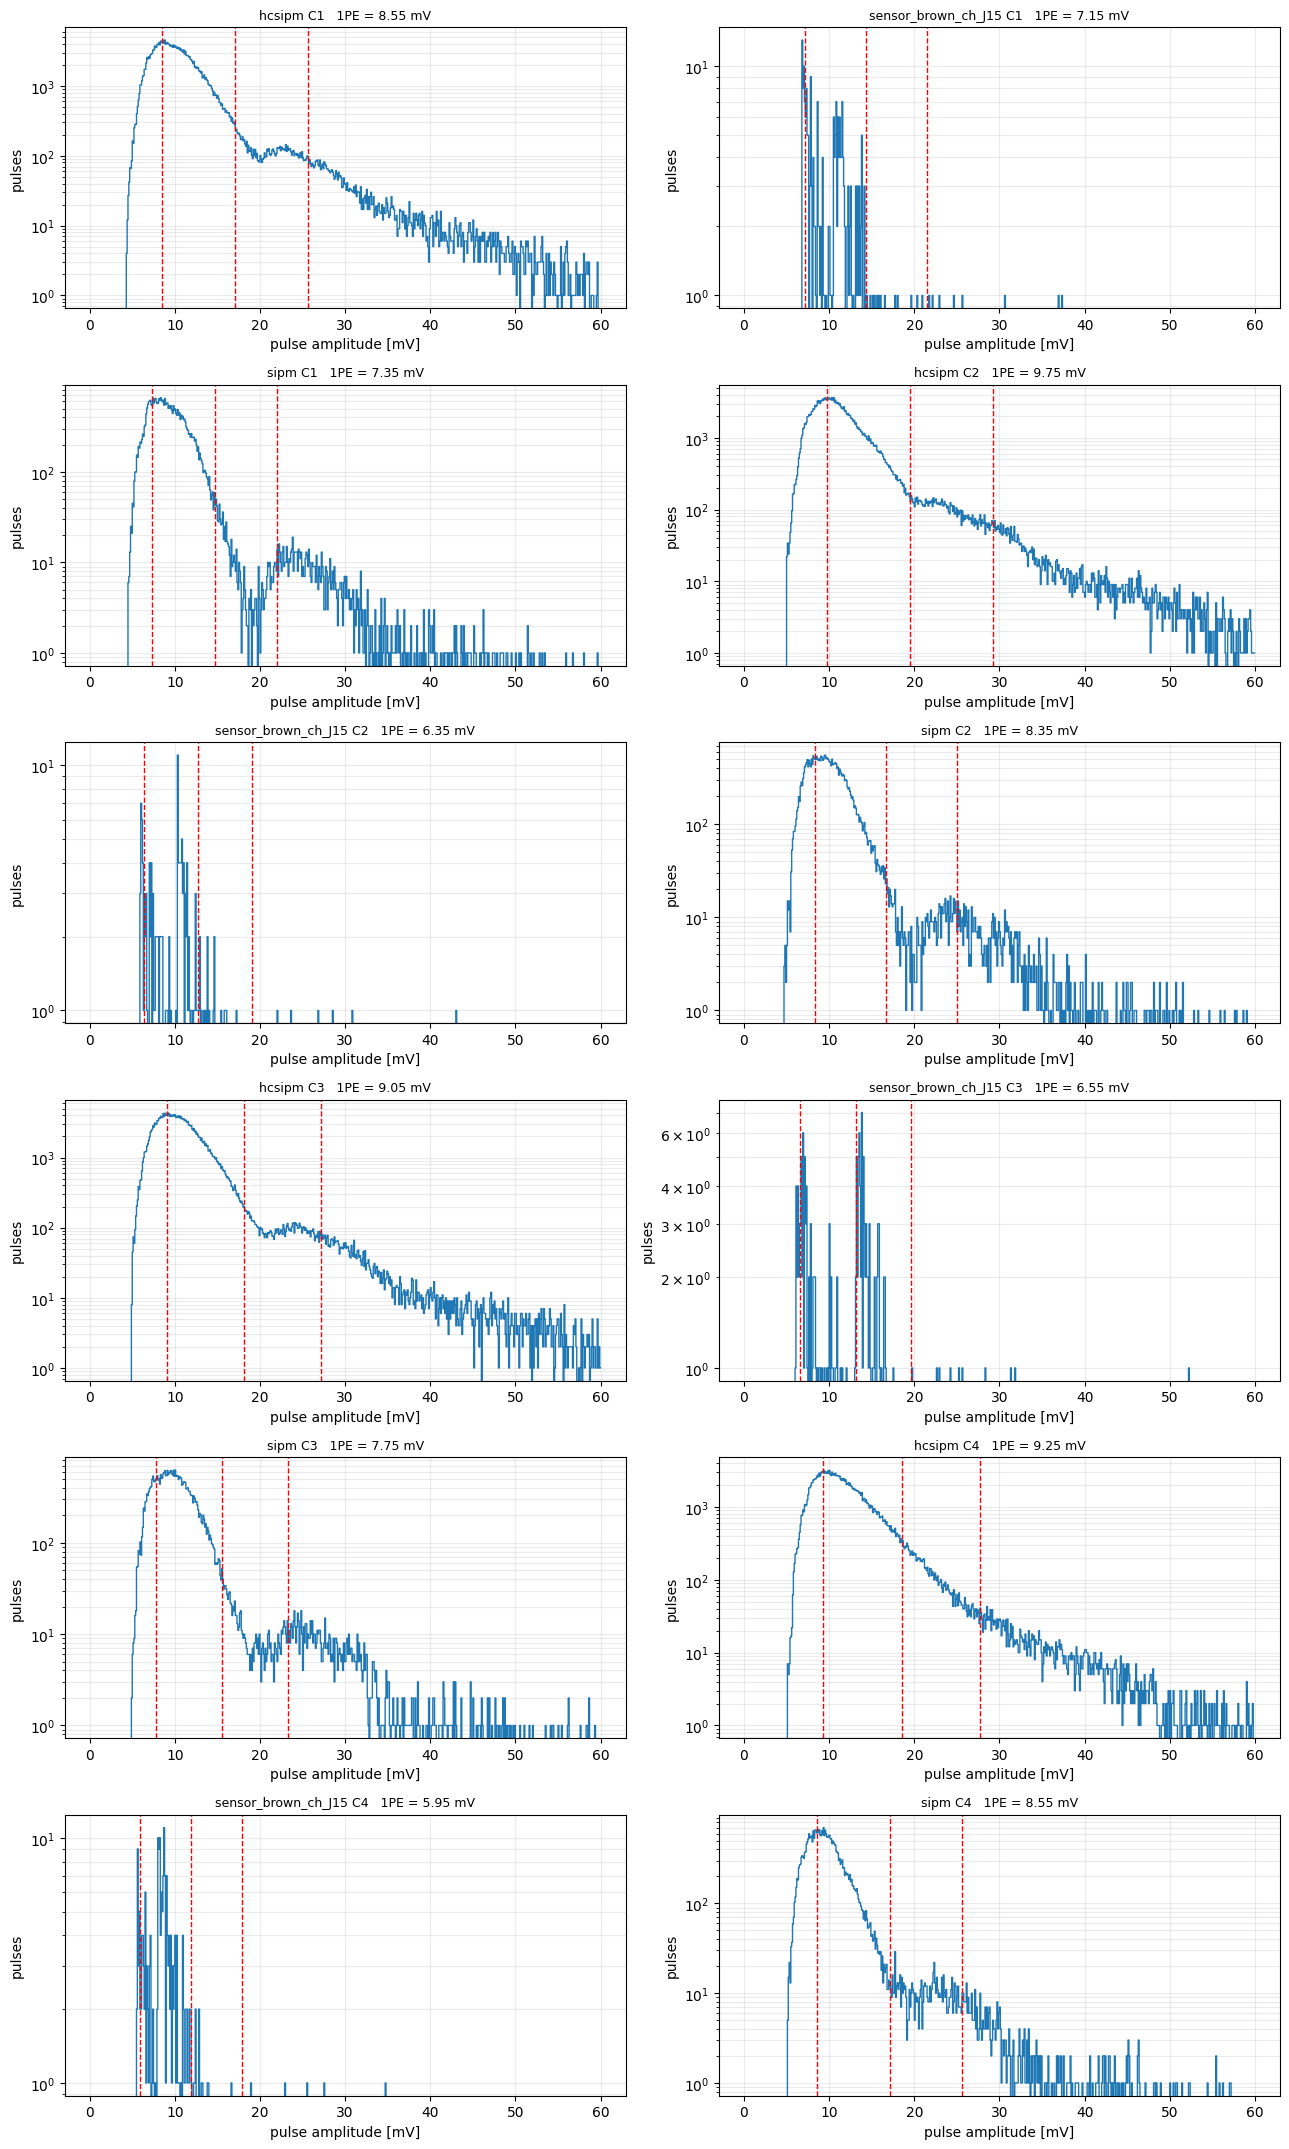

In [102]:
# BACKGROUND 9: pre-trigger pulse amplitude spectrum, single-photoelectron structure
if not pe_hist.empty:
    keys = pe_hist[["device", "channel"]].drop_duplicates().values.tolist()
    nrows = int(np.ceil(len(keys) / 2))
    figure, axes = plt.subplots(nrows, 2, figsize=(13, 3.6 * nrows), squeeze=False)
    for axis, (device, channel) in zip(axes.ravel(), keys):
        h = pe_hist[(pe_hist["device"] == device) & (pe_hist["channel"] == channel)]
        axis.step(h["amplitude_v"] * 1e3, h["counts"], where="mid", lw=1.0)
        if not pe_estimate.empty:
            e = pe_estimate[(pe_estimate["device"] == device) & (pe_estimate["channel"] == channel)]
            if not e.empty and np.isfinite(e.iloc[0]["pe1_amplitude_v"]):
                pe1 = e.iloc[0]["pe1_amplitude_v"] * 1e3
                for n in (1, 2, 3):
                    axis.axvline(n * pe1, color="red", ls="--", lw=1.0)
                axis.set_title(f"{device} {channel}   1PE = {pe1:.2f} mV", fontsize=9)
            else:
                axis.set_title(f"{device} {channel}   no PE peak found", fontsize=9)
        axis.set_yscale("log")
        axis.set_xlabel("pulse amplitude [mV]")
        axis.set_ylabel("pulses")
        axis.grid(alpha=0.25, which="both")
    for axis in axes.ravel()[len(keys):]:
        axis.axis("off")
    finish(figure, "bg09_pe_spectrum")

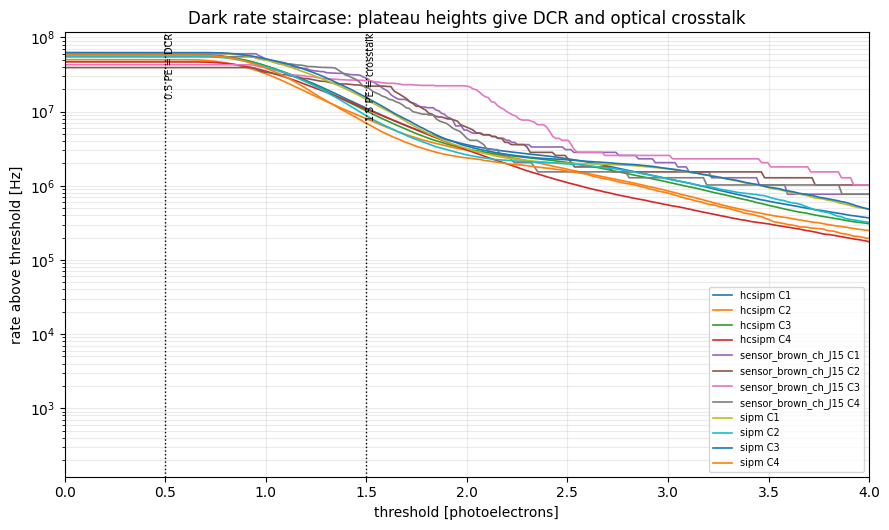

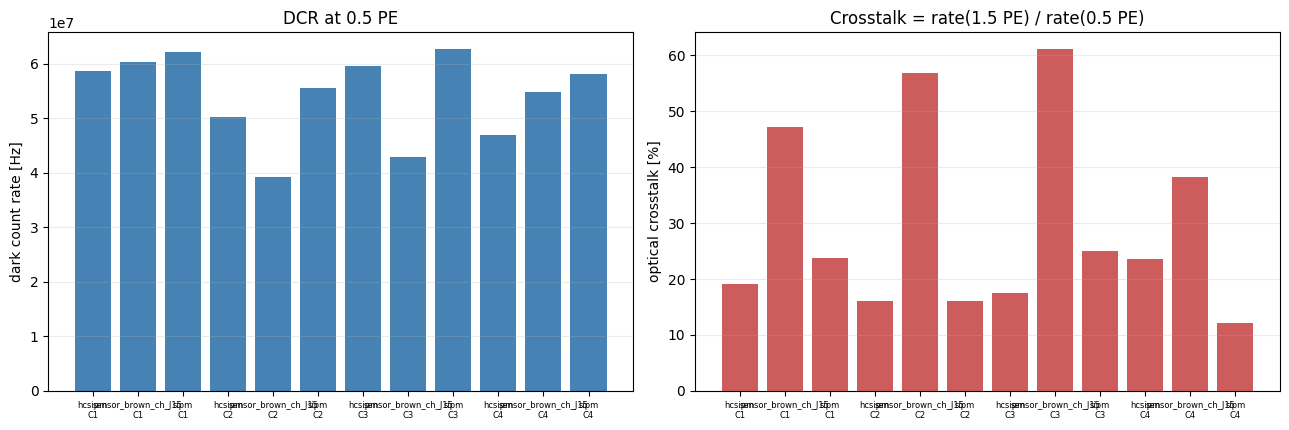

In [103]:
# BACKGROUND 10: dark count rate staircase, plateaus give DCR and crosstalk
if not staircase.empty:
    figure, axis = plt.subplots(figsize=(9, 5.4))
    for (device, channel), group in staircase.groupby(["device", "channel"]):
        ordered = group.sort_values("threshold_v")
        pe1 = np.nan
        if not pe_estimate.empty:
            e = pe_estimate[(pe_estimate["device"] == device) & (pe_estimate["channel"] == channel)]
            if not e.empty:
                pe1 = e.iloc[0]["pe1_amplitude_v"]
        x = ordered["threshold_v"] / pe1 if np.isfinite(pe1) and pe1 > 0 else ordered["threshold_v"] * 1e3
        axis.semilogy(x, ordered["rate_hz"], lw=1.2, label=f"{device} {channel}")
    unit = "photoelectrons" if not pe_estimate.empty and np.isfinite(pe_estimate["pe1_amplitude_v"]).any() else "mV"
    if unit == "photoelectrons":
        for level, name in ((0.5, "0.5 PE = DCR"), (1.5, "1.5 PE = crosstalk")):
            axis.axvline(level, color="black", ls=":", lw=1.0)
            axis.text(level, axis.get_ylim()[1], name, rotation=90, fontsize=7, va="top")
        axis.set_xlim(0, 4)
    axis.set_xlabel(f"threshold [{unit}]")
    axis.set_ylabel("rate above threshold [Hz]")
    axis.set_title("Dark rate staircase: plateau heights give DCR and optical crosstalk")
    axis.grid(alpha=0.25, which="both")
    axis.legend(fontsize=7)
    finish(figure, "bg10_dark_rate_staircase")

if not pe_estimate.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    labels = [f"{r.device}\n{r.channel}" for r in pe_estimate.itertuples()]
    x = np.arange(len(pe_estimate))
    axes[0].bar(x, pe_estimate["dark_count_rate_hz"], color="steelblue")
    axes[0].set_ylabel("dark count rate [Hz]")
    axes[0].set_title("DCR at 0.5 PE")
    axes[1].bar(x, pe_estimate["optical_crosstalk_probability"] * 100, color="indianred")
    axes[1].set_ylabel("optical crosstalk [%]")
    axes[1].set_title("Crosstalk = rate(1.5 PE) / rate(0.5 PE)")
    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels(labels, fontsize=6)
        axis.grid(alpha=0.25, axis="y")
    finish(figure, "bg11_dcr_crosstalk")

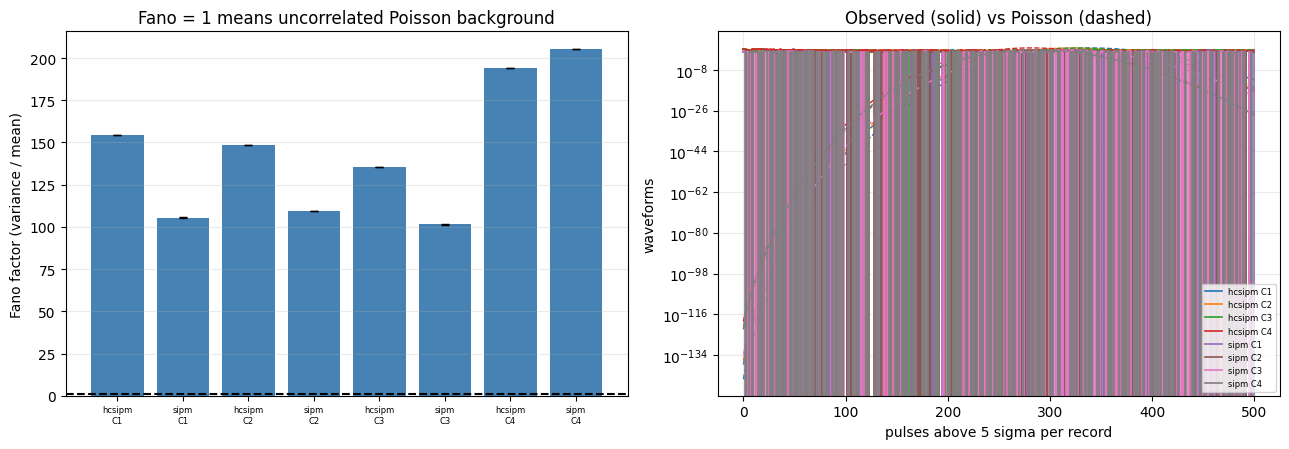

In [104]:
# BACKGROUND 12: are the background counts Poisson?
if not poisson.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    labels = [f"{r.device}\n{r.channel}" for r in poisson.itertuples()]
    x = np.arange(len(poisson))
    axes[0].bar(x, poisson["fano_factor"], yerr=poisson["fano_uncertainty"],
                capsize=3, color="steelblue")
    axes[0].axhline(1.0, color="black", ls="--", lw=1.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=6)
    axes[0].set_ylabel("Fano factor (variance / mean)")
    axes[0].set_title("Fano = 1 means uncorrelated Poisson background")
    axes[0].grid(alpha=0.25, axis="y")
    if not poisson_dist.empty:
        for (device, channel), group in poisson_dist.groupby(["device", "channel"]):
            ordered = group.sort_values("n_pulses")
            line = axes[1].step(ordered["n_pulses"], ordered["observed"], where="mid",
                                lw=1.2, label=f"{device} {channel}")
            axes[1].plot(ordered["n_pulses"], ordered["poisson_expected"], "--", lw=1.0,
                         color=line[0].get_color())
        axes[1].set_yscale("log")
        axes[1].set_xlabel("pulses above 5 sigma per record")
        axes[1].set_ylabel("waveforms")
        axes[1].set_title("Observed (solid) vs Poisson (dashed)")
        axes[1].grid(alpha=0.25, which="both")
        axes[1].legend(fontsize=6)
    finish(figure, "bg12_poisson_test")

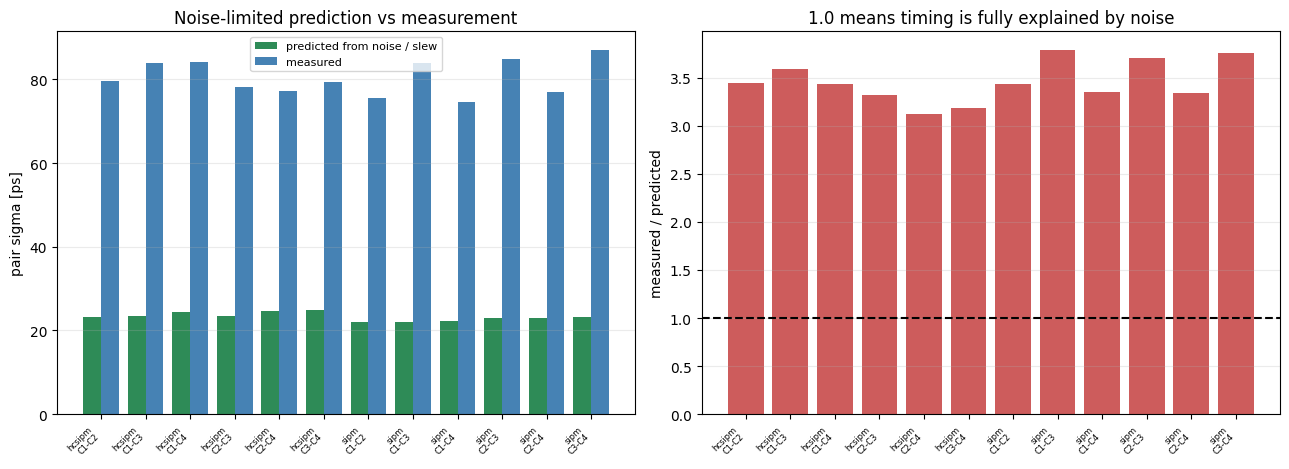

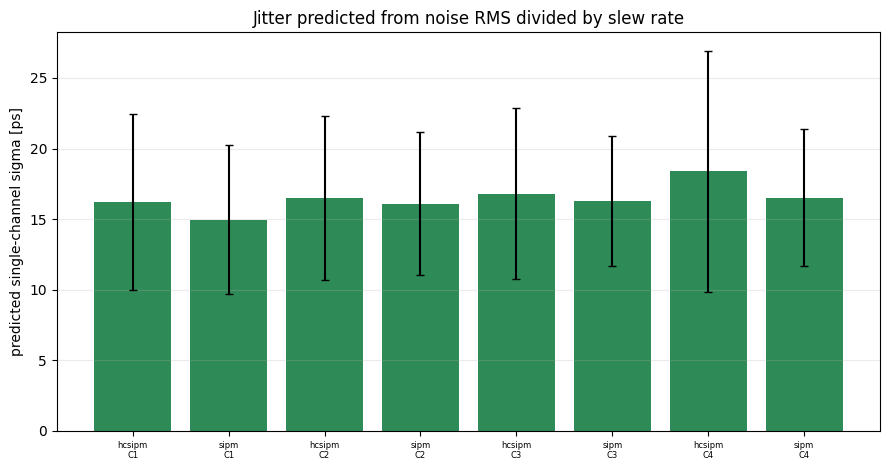

In [105]:
# TIMING 0: does the noise explain the measured timing resolution?
if not predicted_vs_measured.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    labels = [f"{r.coincidence_run}\n{r.channel_a}-{r.channel_b}"
              for r in predicted_vs_measured.itertuples()]
    x = np.arange(len(predicted_vs_measured))
    axes[0].bar(x - 0.2, predicted_vs_measured["predicted_pair_sigma_ps"], 0.4,
                label="predicted from noise / slew", color="seagreen")
    axes[0].bar(x + 0.2, predicted_vs_measured["measured_pair_sigma_ps"], 0.4,
                label="measured", color="steelblue")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    axes[0].set_ylabel("pair sigma [ps]")
    axes[0].set_title("Noise-limited prediction vs measurement")
    axes[0].legend(fontsize=8)
    axes[1].bar(x, predicted_vs_measured["measured_over_predicted"], color="indianred")
    axes[1].axhline(1.0, color="black", ls="--", lw=1.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    axes[1].set_ylabel("measured / predicted")
    axes[1].set_title("1.0 means timing is fully explained by noise")
    for axis in axes:
        axis.grid(alpha=0.25, axis="y")
    finish(figure, "tm00_noise_limited_prediction")

if not prediction.empty:
    figure, axis = plt.subplots(figsize=(9, 4.8))
    labels = [f"{r.device}\n{r.channel}" for r in prediction.itertuples()]
    x = np.arange(len(prediction))
    axis.bar(x, prediction["predicted_sigma_ps"], yerr=prediction["predicted_sigma_spread_ps"],
             capsize=3, color="seagreen")
    axis.set_xticks(x)
    axis.set_xticklabels(labels, fontsize=6)
    axis.set_ylabel("predicted single-channel sigma [ps]")
    axis.set_title("Jitter predicted from noise RMS divided by slew rate")
    axis.grid(alpha=0.25, axis="y")
    finish(figure, "tm00b_predicted_channel_jitter")

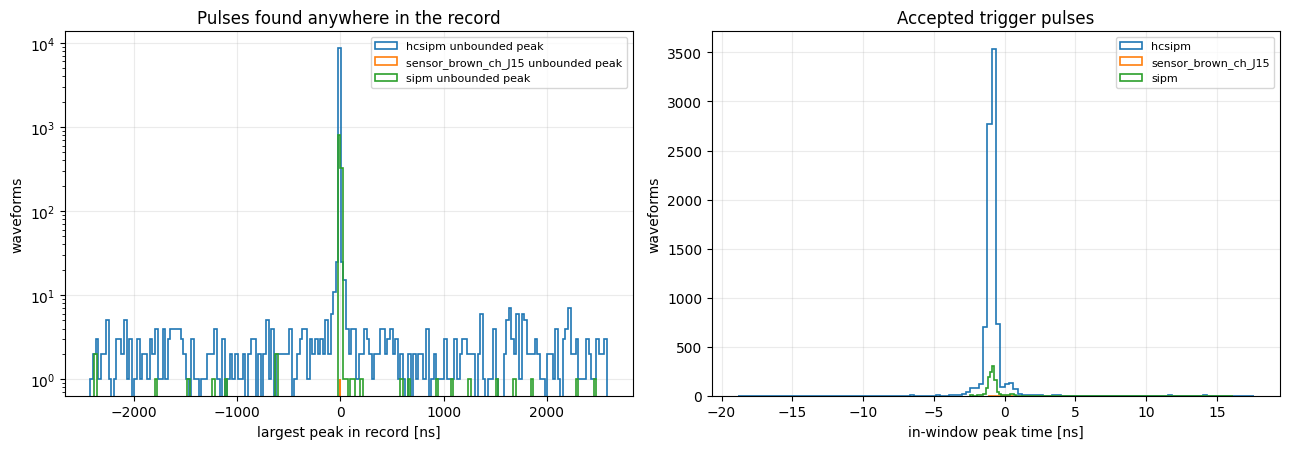

In [106]:
# TIMING 1: where the pulse sits, against the search window
if not physical.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for device in devices:
        subset = physical[physical["device"] == device]
        axes[0].hist(pd.to_numeric(subset["t_global_peak_ns"], errors="coerce").dropna(),
                     bins=200, histtype="step", lw=1.2, label=f"{device} unbounded peak")
        axes[1].hist(pd.to_numeric(subset.loc[subset["timing_valid"].astype(bool), "t_peak_ns"],
                                   errors="coerce").dropna(), bins=120, histtype="step", lw=1.2, label=device)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("largest peak in record [ns]")
    axes[0].set_title("Pulses found anywhere in the record")
    axes[1].set_xlabel("in-window peak time [ns]")
    axes[1].set_title("Accepted trigger pulses")
    for axis in axes:
        axis.set_ylabel("waveforms")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    finish(figure, "tm01_peak_location")

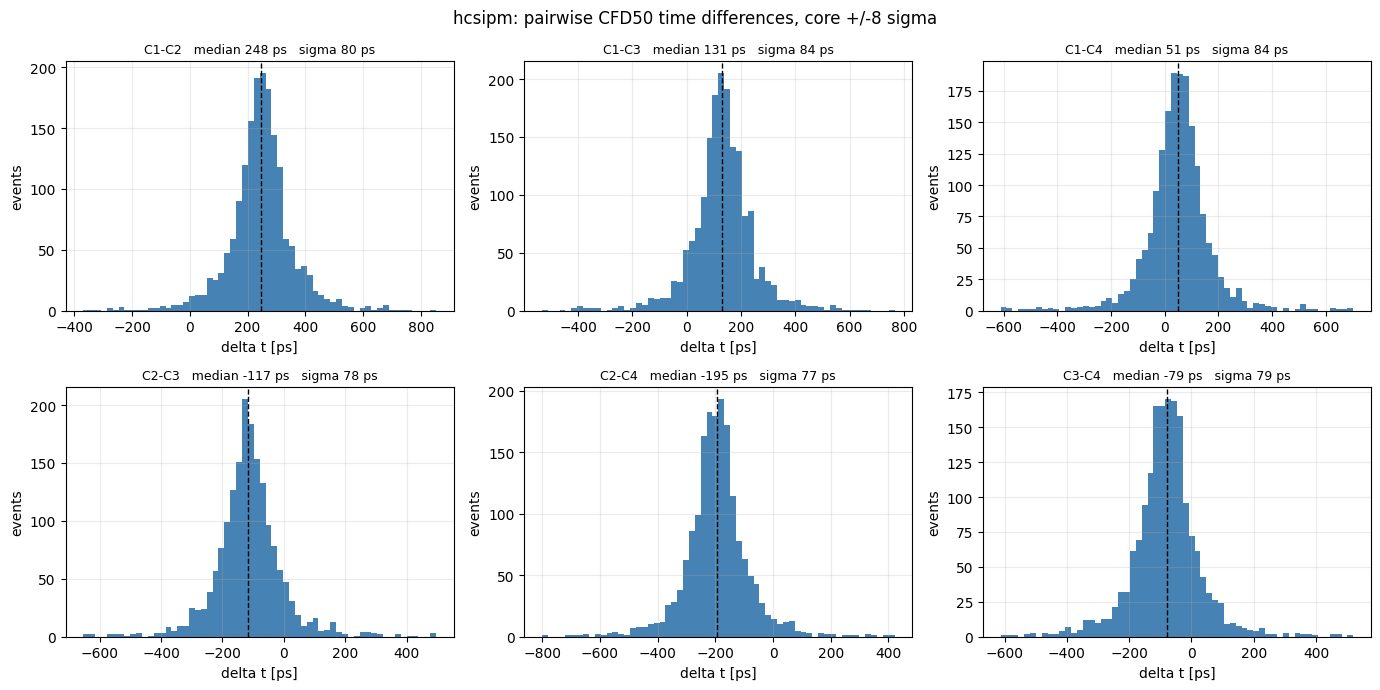

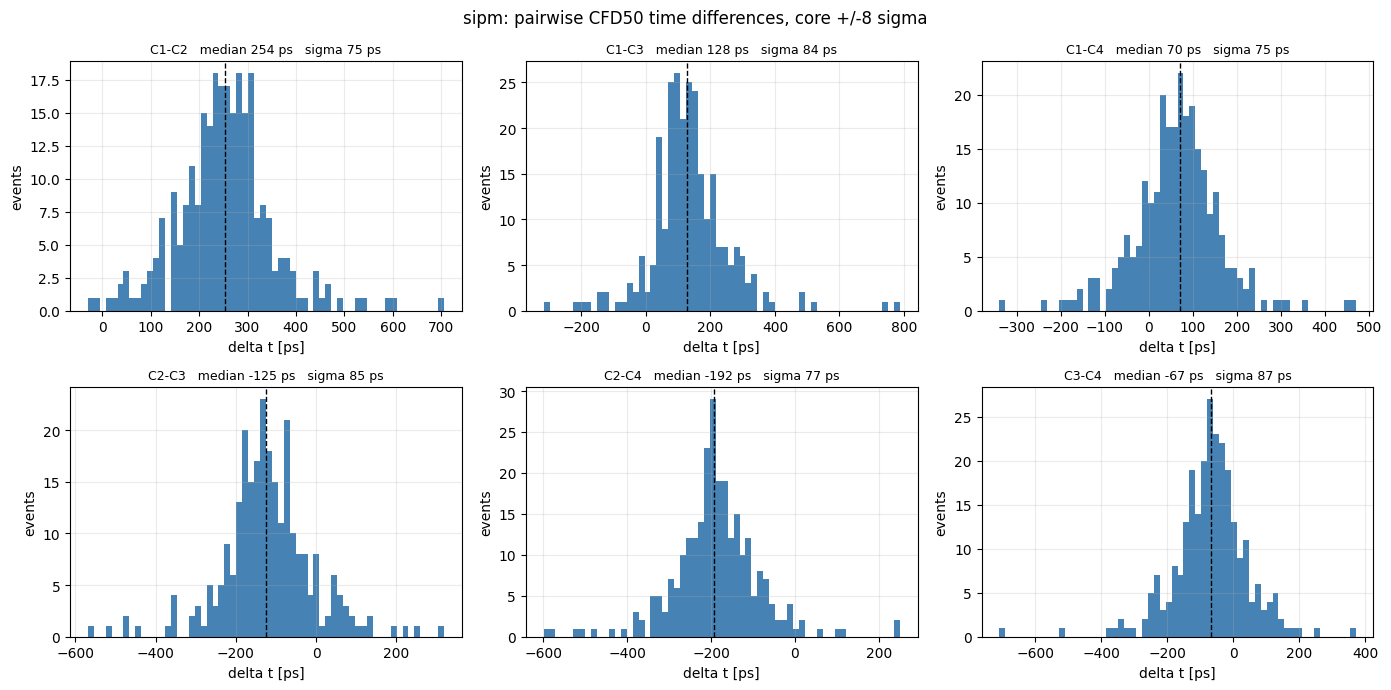

In [107]:
# TIMING 2: pairwise delta-t distributions
for run in runs:
    subset = pairwise[pairwise["coincidence_run"] == run]
    figure, axes = plt.subplots(2, 3, figsize=(14, 7))
    for axis, (a, b) in zip(axes.ravel(), itertools.combinations(CHANNELS, 2)):
        v = pd.to_numeric(subset[(subset["channel_a"] == a) & (subset["channel_b"] == b)]["delta_t_ns"],
                          errors="coerce").dropna()
        if v.empty:
            continue
        median = float(v.median())
        sigma = 1.4826 * float(np.median(np.abs(v - median)))
        core = v[np.abs(v - median) <= 8 * max(sigma, 1e-6)]
        axis.hist(core * 1e3, bins=60, color="steelblue")
        axis.axvline(median * 1e3, color="black", ls="--", lw=1)
        axis.set_title(f"{a}-{b}   median {median * 1e3:.0f} ps   sigma {sigma * 1e3:.0f} ps", fontsize=9)
        axis.set_xlabel("delta t [ps]")
        axis.set_ylabel("events")
        axis.grid(alpha=0.25)
    figure.suptitle(f"{run}: pairwise CFD50 time differences, core +/-8 sigma")
    finish(figure, f"tm02_delta_t_{run}")

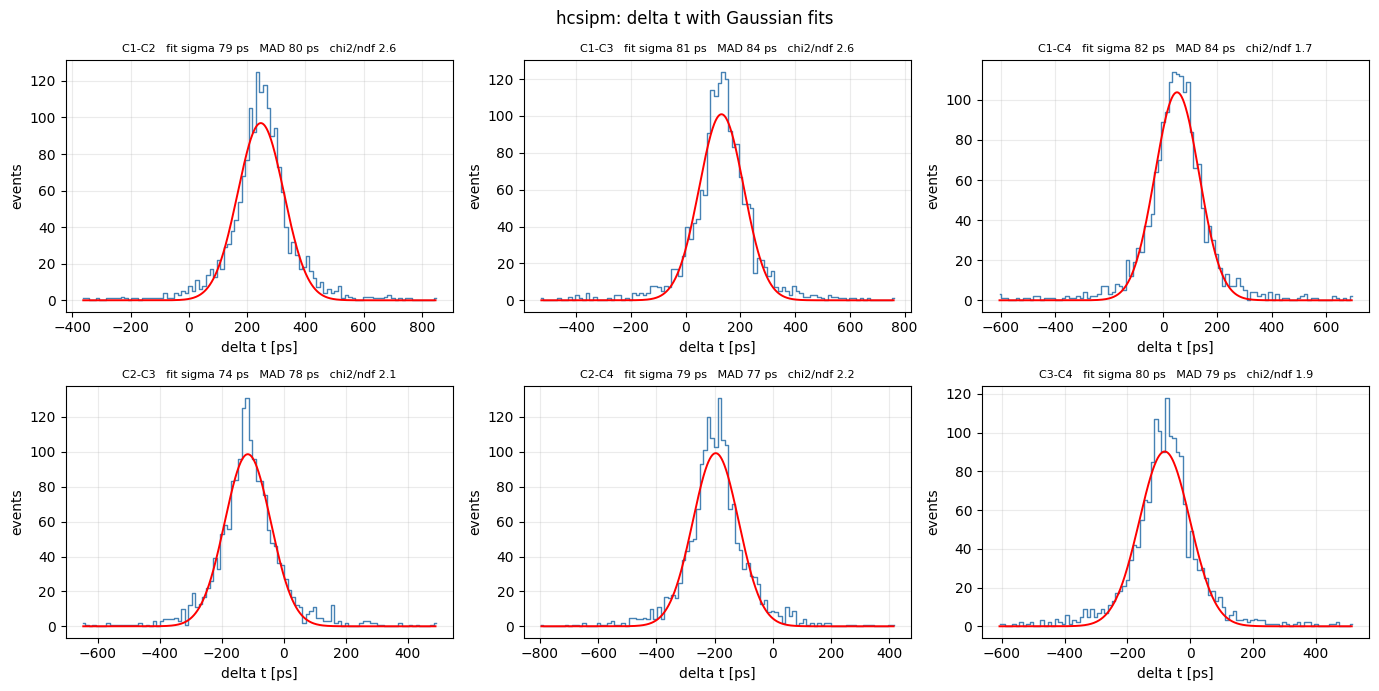

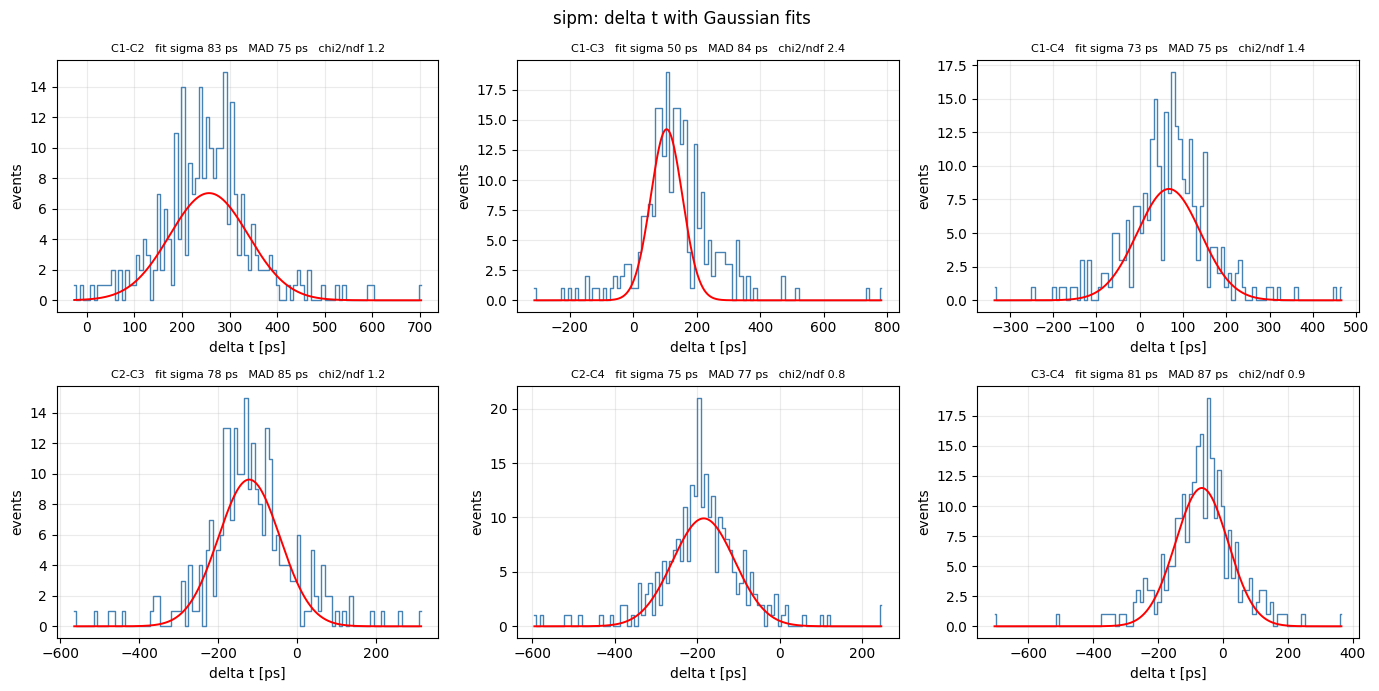

In [108]:
# TIMING 2b: Gaussian fits to the delta-t distributions
if not delta_hist.empty and not delta_fit.empty:
    fits = delta_fit[delta_fit["timing_column"] == "delta_t_ns"]
    for run in sorted(delta_hist["coincidence_run"].unique()):
        figure, axes = plt.subplots(2, 3, figsize=(14, 7))
        for axis, (a, b) in zip(axes.ravel(), itertools.combinations(CHANNELS, 2)):
            h = delta_hist[(delta_hist["coincidence_run"] == run) &
                           (delta_hist["channel_a"] == a) & (delta_hist["channel_b"] == b)]
            f = fits[(fits["coincidence_run"] == run) &
                     (fits["channel_a"] == a) & (fits["channel_b"] == b)]
            if h.empty:
                continue
            x = h["bin_center_ps"].to_numpy(float)
            axis.step(x, h["counts"].to_numpy(float), where="mid", lw=1.0, color="steelblue")
            if not f.empty and bool(f.iloc[0].get("fit_ok", False)):
                row = f.iloc[0]
                grid = np.linspace(x.min(), x.max(), 800)
                axis.plot(grid, row["fit_amplitude"] *
                          np.exp(-0.5 * ((grid - row["fit_mu_ps"]) / row["fit_sigma_ps"]) ** 2),
                          "r-", lw=1.4)
                axis.set_title(f"{a}-{b}   fit sigma {row['fit_sigma_ps']:.0f} ps   "
                               f"MAD {row['robust_sigma_ps']:.0f} ps   "
                               f"chi2/ndf {row['fit_chi2_per_ndf']:.1f}", fontsize=8)
            axis.set_xlabel("delta t [ps]")
            axis.set_ylabel("events")
            axis.grid(alpha=0.25)
        figure.suptitle(f"{run}: delta t with Gaussian fits")
        finish(figure, f"tm02b_delta_t_fits_{run}")

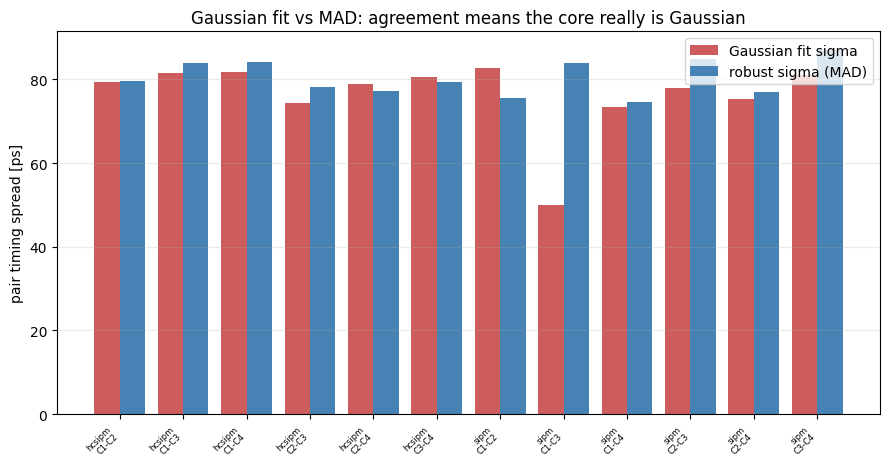

In [109]:
# TIMING 2c: fitted sigma vs robust sigma
if not delta_fit.empty:
    base = delta_fit[delta_fit["timing_column"] == "delta_t_ns"]
    figure, axis = plt.subplots(figsize=(9, 4.8))
    labels = [f"{r.coincidence_run}\n{r.channel_a}-{r.channel_b}" for r in base.itertuples()]
    x = np.arange(len(base))
    axis.bar(x - 0.2, base["fit_sigma_ps"], 0.4, label="Gaussian fit sigma", color="indianred")
    axis.bar(x + 0.2, base["robust_sigma_ps"], 0.4, label="robust sigma (MAD)", color="steelblue")
    axis.set_xticks(x)
    axis.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    axis.set_ylabel("pair timing spread [ps]")
    axis.set_title("Gaussian fit vs MAD: agreement means the core really is Gaussian")
    axis.grid(alpha=0.25, axis="y")
    axis.legend()
    finish(figure, "tm02c_fit_vs_robust")

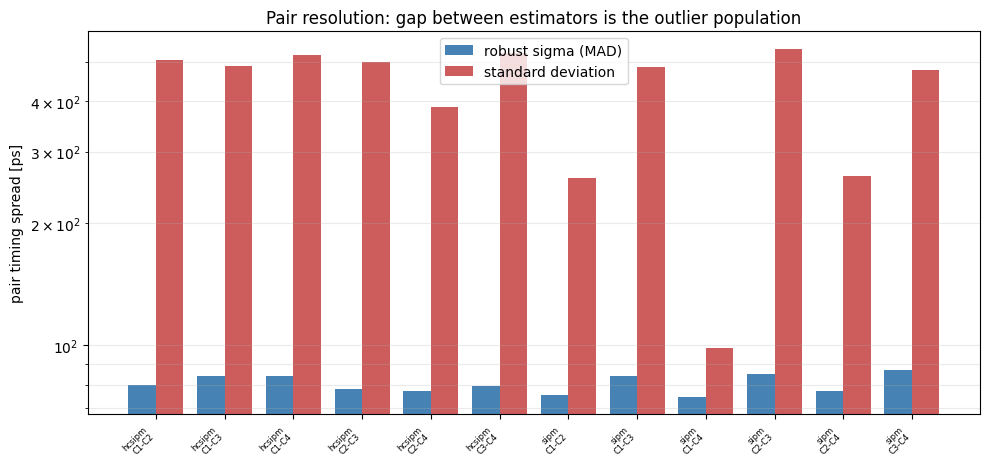

In [110]:
# TIMING 3: pair resolution, robust vs standard
if not raw_pairs.empty:
    figure, axis = plt.subplots(figsize=(10, 4.8))
    labels = [f"{r.coincidence_run}\n{r.channel_a}-{r.channel_b}" for r in raw_pairs.itertuples()]
    x = np.arange(len(raw_pairs))
    axis.bar(x - 0.2, raw_pairs["robust_sigma_ps"], 0.4, label="robust sigma (MAD)", color="steelblue")
    axis.bar(x + 0.2, raw_pairs["std_all_ps"], 0.4, label="standard deviation", color="indianred")
    axis.set_yscale("log")
    axis.set_xticks(x)
    axis.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    axis.set_ylabel("pair timing spread [ps]")
    axis.set_title("Pair resolution: gap between estimators is the outlier population")
    axis.grid(alpha=0.25, axis="y", which="both")
    axis.legend()
    finish(figure, "tm03_pair_resolution")

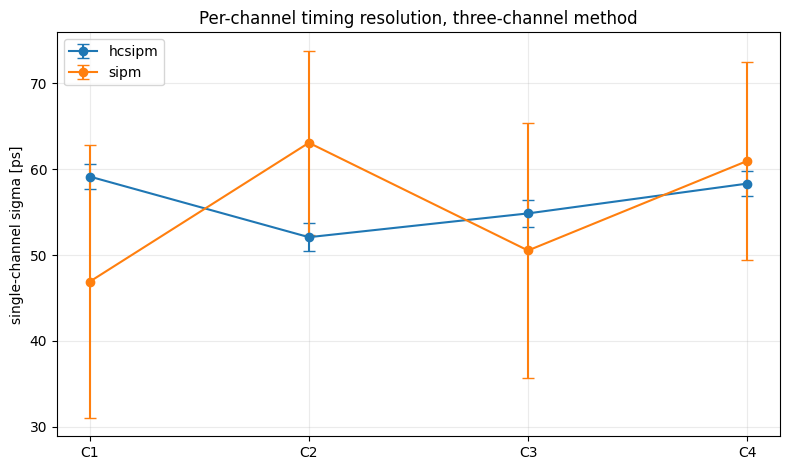

In [111]:
# TIMING 4: single-channel resolution from the three-channel decomposition
if not resolution.empty:
    base = resolution[resolution["timing_column"] == "delta_t_ns"]
    figure, axis = plt.subplots(figsize=(8, 4.8))
    for run, group in base.groupby("coincidence_run"):
        ordered = group.sort_values("channel")
        axis.errorbar(ordered["channel"], ordered["sigma_channel_ps"],
                      yerr=ordered["sigma_channel_spread_ps"], fmt="o-", capsize=4, label=run)
    axis.set_ylabel("single-channel sigma [ps]")
    axis.set_title("Per-channel timing resolution, three-channel method")
    axis.grid(alpha=0.25)
    axis.legend()
    finish(figure, "tm04_channel_resolution")

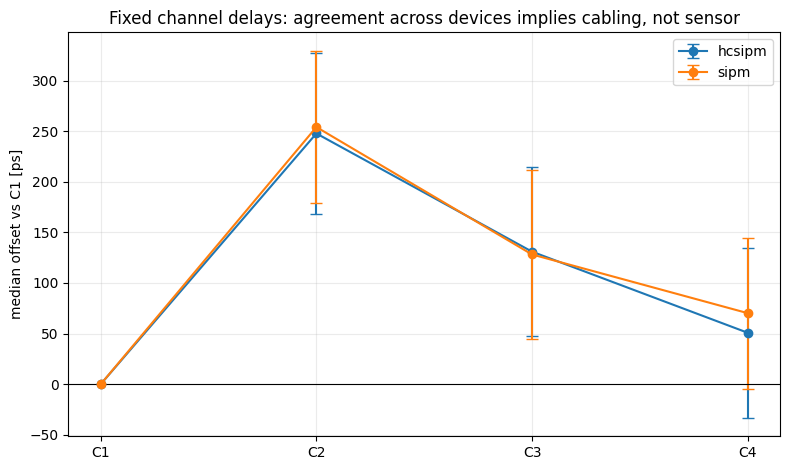

In [112]:
# TIMING 5: fixed channel offsets, cross-checked between devices
if not offsets.empty:
    figure, axis = plt.subplots(figsize=(8, 4.8))
    for run, group in offsets.groupby("coincidence_run"):
        ordered = group.sort_values("channel")
        axis.errorbar(ordered["channel"], ordered["median_offset_ps"],
                      yerr=ordered["robust_sigma_ps"], fmt="o-", capsize=4, label=run)
    axis.axhline(0, color="black", lw=0.8)
    axis.set_ylabel("median offset vs C1 [ps]")
    axis.set_title("Fixed channel delays: agreement across devices implies cabling, not sensor")
    axis.grid(alpha=0.25)
    axis.legend()
    finish(figure, "tm05_channel_offsets")

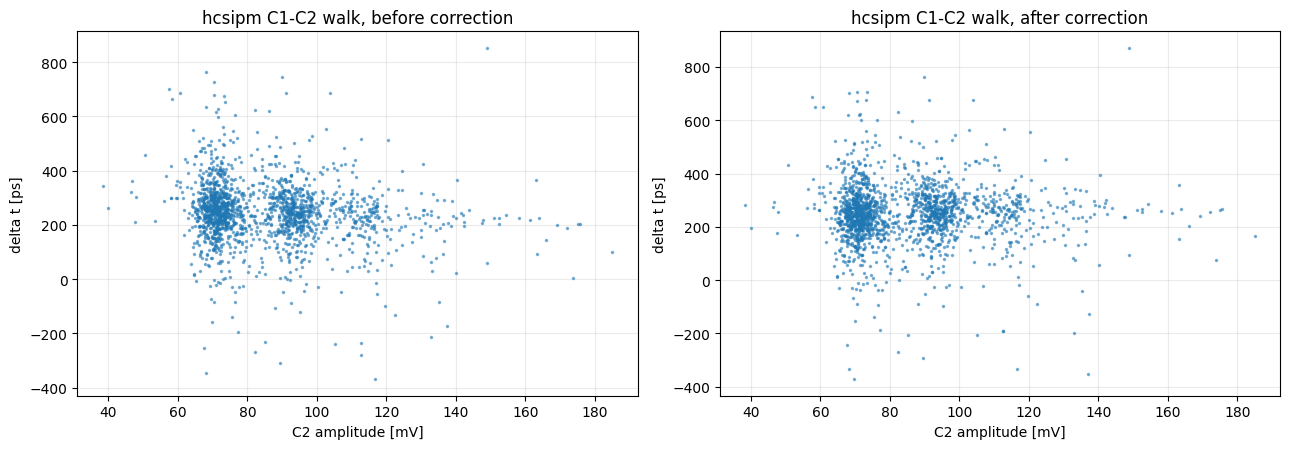

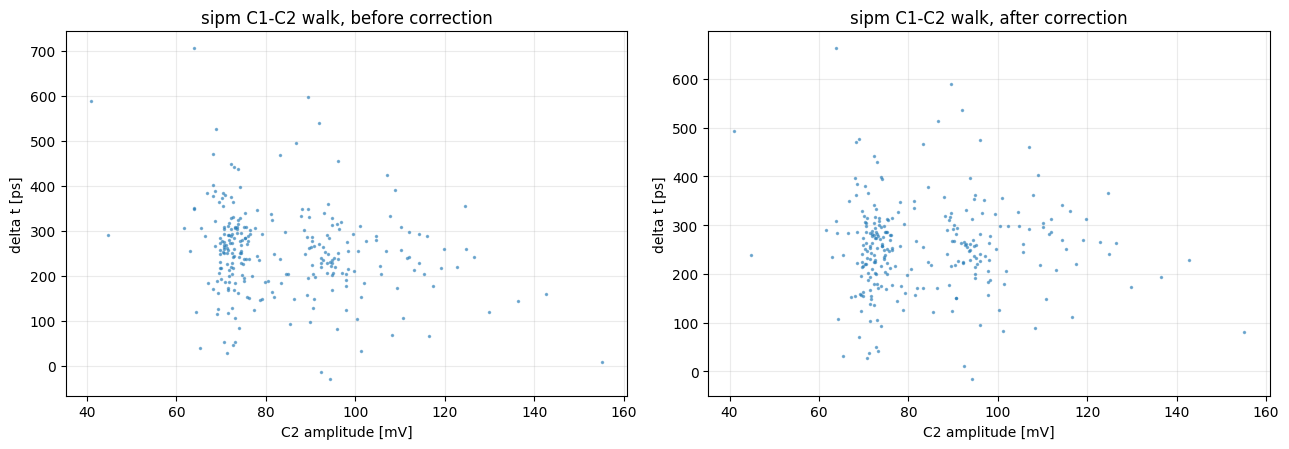

In [113]:
# TIMING 6: amplitude time walk, before and after correction
if not pairwise.empty and "delta_t_corrected_ns" in pairwise.columns:
    for run in runs:
        subset = pairwise[(pairwise["coincidence_run"] == run) &
                          (pairwise["channel_a"] == "C1") & (pairwise["channel_b"] == "C2")]
        if subset.empty:
            continue
        figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
        amplitude = pd.to_numeric(subset["amplitude_b_v"], errors="coerce") * 1e3
        for axis, column, title in ((axes[0], "delta_t_ns", "before"), (axes[1], "delta_t_corrected_ns", "after")):
            v = pd.to_numeric(subset[column], errors="coerce")
            median = float(v.median())
            sigma = 1.4826 * float(np.median(np.abs(v - median)))
            keep = np.abs(v - median) <= 8 * max(sigma, 1e-6)
            axis.plot(amplitude[keep], v[keep] * 1e3, ".", ms=3, alpha=0.5)
            axis.set_xlabel("C2 amplitude [mV]")
            axis.set_ylabel("delta t [ps]")
            axis.set_title(f"{run} C1-C2 walk, {title} correction")
            axis.grid(alpha=0.25)
        finish(figure, f"tm06_time_walk_{run}")

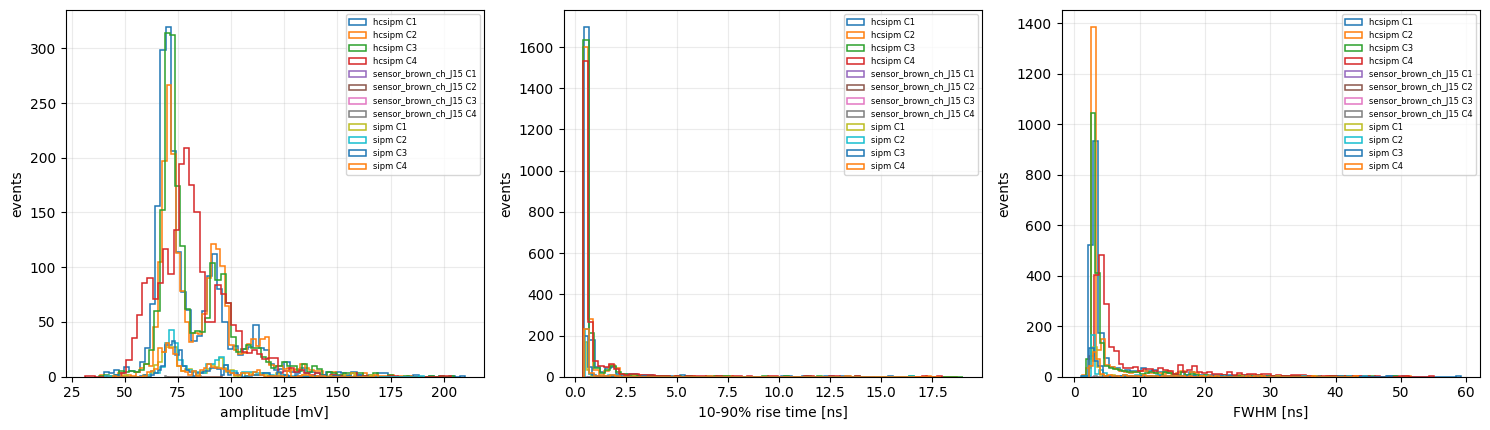

In [114]:
# TIMING 7: pulse shape
if not valid.empty:
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for (device, channel), group in valid.groupby(["device", "channel"]):
        label = f"{device} {channel}"
        axes[0].hist(pd.to_numeric(group["amplitude_v"], errors="coerce").dropna() * 1e3,
                     bins=70, histtype="step", lw=1.1, label=label)
        axes[1].hist(pd.to_numeric(group["rise_10_90_ns"], errors="coerce").dropna(),
                     bins=70, histtype="step", lw=1.1, label=label)
        axes[2].hist(pd.to_numeric(group["fwhm_ns"], errors="coerce").dropna(),
                     bins=70, histtype="step", lw=1.1, label=label)
    axes[0].set_xlabel("amplitude [mV]")
    axes[1].set_xlabel("10-90% rise time [ns]")
    axes[2].set_xlabel("FWHM [ns]")
    for axis in axes:
        axis.set_ylabel("events")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=6)
    finish(figure, "tm07_pulse_shape")

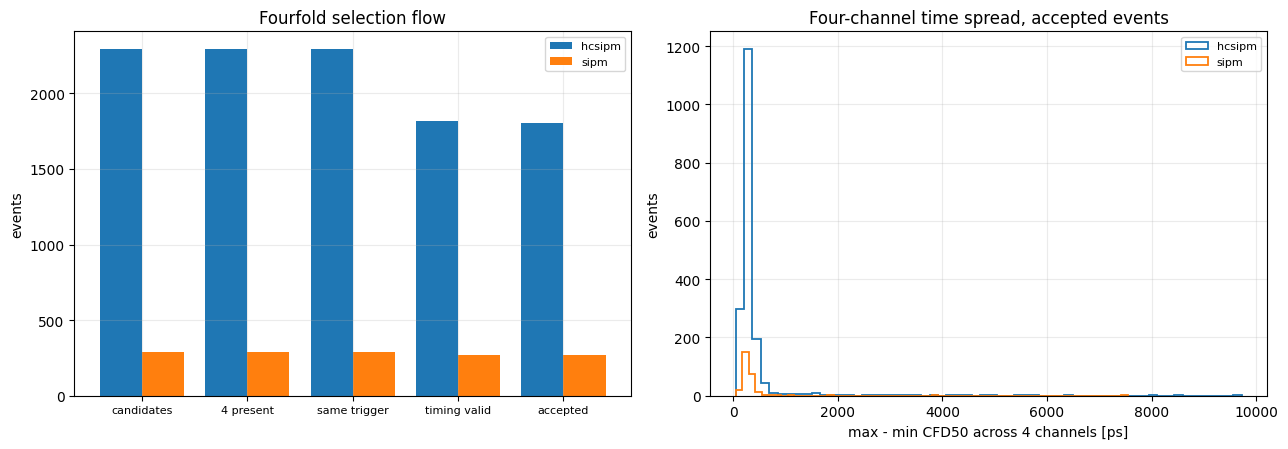

In [115]:
# TIMING 8: selection flow and four-channel spread
if not coincidence.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    stages = [("n_candidate_events", "candidates"), ("n_complete_fourfold", "4 present"),
              ("n_same_trigger", "same trigger"), ("n_all_timing_valid", "timing valid"),
              ("n_accepted_fourfold", "accepted")]
    stages = [(c, l) for c, l in stages if c in coincidence.columns]
    x = np.arange(len(stages))
    width = 0.8 / max(1, len(coincidence))
    for i, (_, row) in enumerate(coincidence.iterrows()):
        axes[0].bar(x + i * width, [row[c] for c, _ in stages], width, label=row["coincidence_run"])
    axes[0].set_xticks(x + width * (len(coincidence) - 1) / 2)
    axes[0].set_xticklabels([l for _, l in stages], fontsize=8)
    axes[0].set_ylabel("events")
    axes[0].set_title("Fourfold selection flow")
    axes[0].legend(fontsize=8)

    if not event_status.empty:
        for run, group in event_status.groupby("coincidence_run"):
            v = pd.to_numeric(group.loc[group["accepted_fourfold"].astype(bool), "time_spread_ns"],
                              errors="coerce").dropna()
            if not v.empty:
                axes[1].hist(v * 1e3, bins=60, histtype="step", lw=1.3, label=run)
        axes[1].set_xlabel("max - min CFD50 across 4 channels [ps]")
        axes[1].set_ylabel("events")
        axes[1].set_title("Four-channel time spread, accepted events")
        axes[1].legend(fontsize=8)
    for axis in axes:
        axis.grid(alpha=0.25)
    finish(figure, "tm08_selection_and_spread")

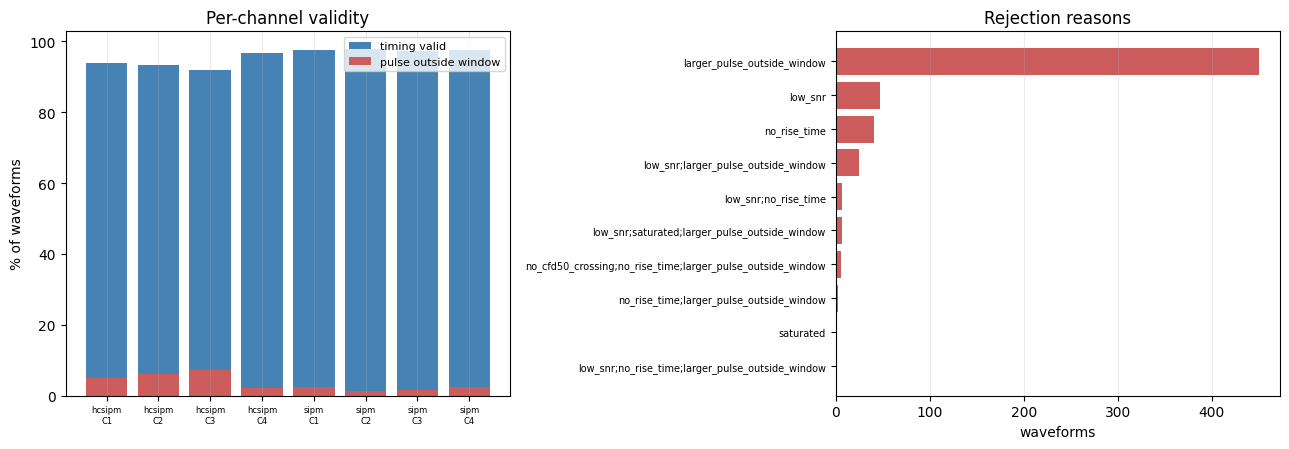

Plots written to C:\Users\firep\Downloads\simple_analysis_script\timing_results_v2\plots


In [116]:
# TIMING 9: validity and rejection breakdown
if not channel_summary.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    labels = [f"{r.device}\n{r.channel}" for r in channel_summary.itertuples()]
    x = np.arange(len(channel_summary))
    axes[0].bar(x, channel_summary["valid_fraction"] * 100, color="steelblue", label="timing valid")
    axes[0].bar(x, channel_summary["frac_peak_outside_window"] * 100, color="indianred",
                label="pulse outside window")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=6)
    axes[0].set_ylabel("% of waveforms")
    axes[0].set_title("Per-channel validity")
    axes[0].legend(fontsize=8)
    if not rejections.empty:
        top = rejections.head(12)
        axes[1].barh(range(len(top)), top["events"], color="indianred")
        axes[1].set_yticks(range(len(top)))
        axes[1].set_yticklabels(top["rejection_reason"], fontsize=7)
        axes[1].invert_yaxis()
        axes[1].set_xlabel("waveforms")
        axes[1].set_title("Rejection reasons")
    for axis in axes:
        axis.grid(alpha=0.25, axis="x")
    finish(figure, "tm09_validity")

print(f"Plots written to {PLOT_DIR}")

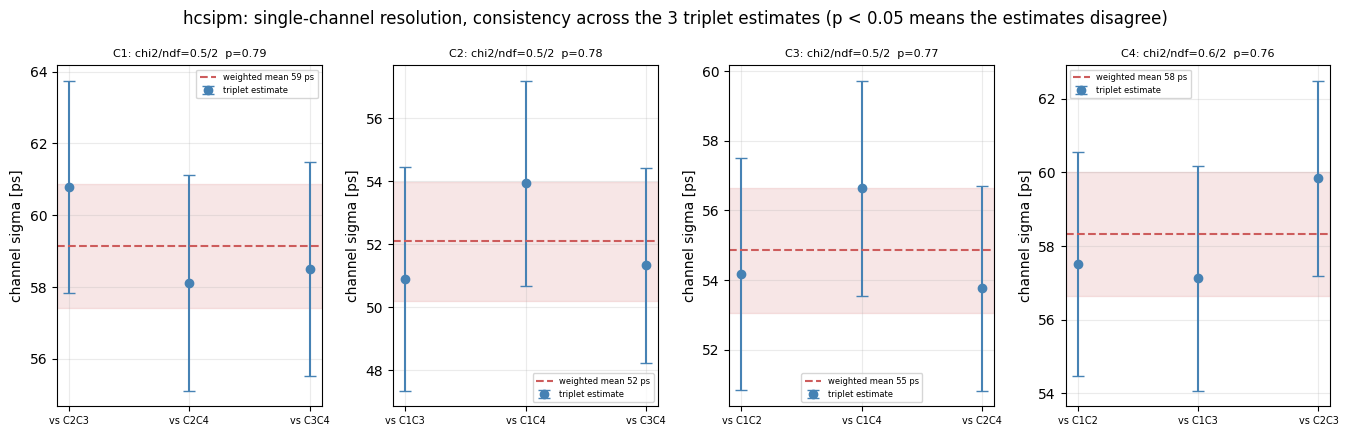

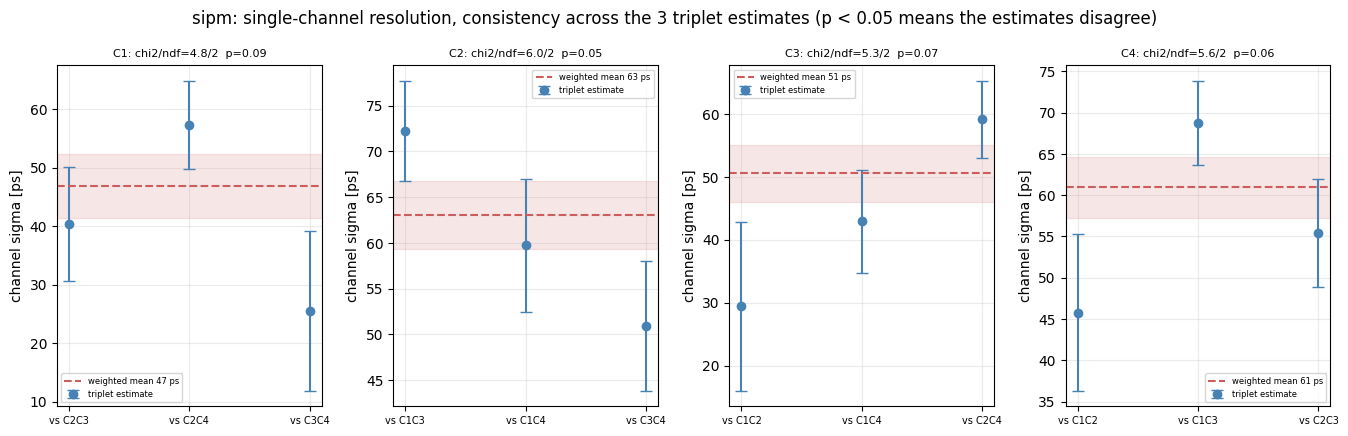

In [117]:
# TIMING 4b: channel-resolution triplet-estimate consistency
# For each channel, the 3-channel decomposition gives 3 independent sigma
# estimates (one per pair of the other 3 channels). This checks whether those
# 3 estimates agree with each other (weighted mean +/- its uncertainty, and a
# chi2/ndf consistency test), which is the direct answer to "how compatible
# are the sigmas across all combinations".
if not triplet_estimates.empty and not resolution.empty:
    base_triplet = triplet_estimates[triplet_estimates["timing_column"] == "delta_t_ns"]
    base_res = resolution[resolution["timing_column"] == "delta_t_ns"]
    for run in sorted(base_triplet["coincidence_run"].unique()):
        figure, axes = plt.subplots(1, len(CHANNELS), figsize=(3.4 * len(CHANNELS), 4.4), squeeze=False)
        axes = axes[0]
        for axis, channel in zip(axes, CHANNELS):
            t = base_triplet[(base_triplet["coincidence_run"] == run) & (base_triplet["channel"] == channel)]
            r = base_res[(base_res["coincidence_run"] == run) & (base_res["channel"] == channel)]
            if t.empty:
                axis.axis("off")
                continue
            labels = [f"vs {a}{b}" for a, b in zip(t["other_b"], t["other_d"])]
            x = np.arange(len(t))
            axis.errorbar(x, t["sigma_channel_ps"], yerr=t["sigma_channel_unc_ps"],
                          fmt="o", capsize=4, color="steelblue", label="triplet estimate")
            title = channel
            if not r.empty:
                row = r.iloc[0]
                if np.isfinite(row["sigma_channel_ps"]):
                    axis.axhline(row["sigma_channel_ps"], color="indianred", ls="--", lw=1.5,
                                 label=f"weighted mean {row['sigma_channel_ps']:.0f} ps")
                    if np.isfinite(row["sigma_channel_unc_ps"]):
                        axis.axhspan(row["sigma_channel_ps"] - row["sigma_channel_unc_ps"],
                                    row["sigma_channel_ps"] + row["sigma_channel_unc_ps"],
                                    color="indianred", alpha=0.15)
                p = row.get("consistency_pvalue", np.nan)
                chi2v, ndfv = row.get("chi2_consistency", np.nan), row.get("ndf_consistency", 0)
                if np.isfinite(p):
                    title = f"{channel}: chi2/ndf={chi2v:.1f}/{int(ndfv)}  p={p:.2f}"
            axis.set_title(title, fontsize=8)
            axis.set_xticks(x)
            axis.set_xticklabels(labels, fontsize=7)
            axis.set_ylabel("channel sigma [ps]")
            axis.grid(alpha=0.25)
            axis.legend(fontsize=6)
        figure.suptitle(f"{run}: single-channel resolution, consistency across the 3 triplet estimates "
                        "(p < 0.05 means the estimates disagree)")
        finish(figure, f"tm04b_triplet_consistency_{run}")

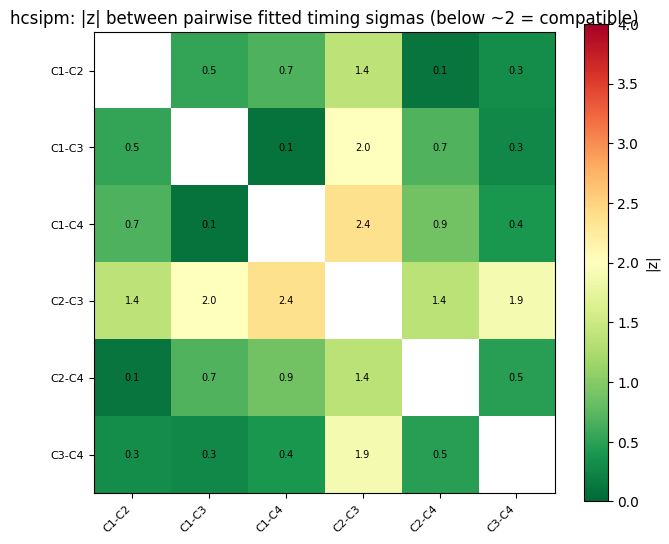

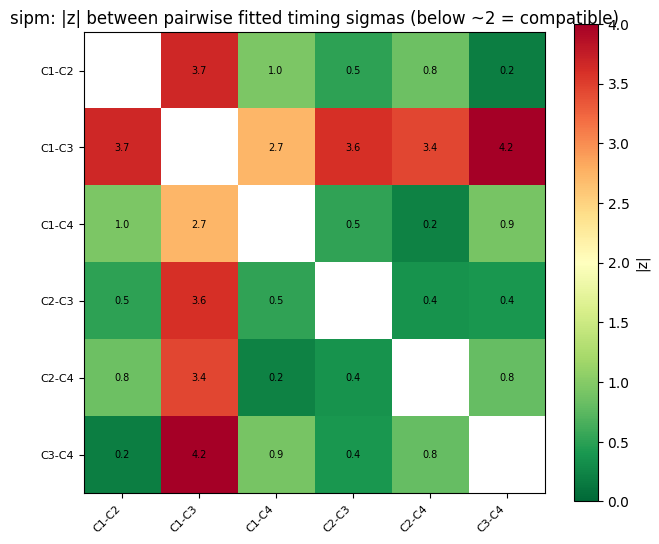

In [118]:
# TIMING 4c: are the 6 pairwise Gaussian-fit timing sigmas mutually compatible?
if not pair_sigma_compat.empty:
    for run in sorted(pair_sigma_compat["coincidence_run"].unique()):
        sub = pair_sigma_compat[pair_sigma_compat["coincidence_run"] == run].copy()
        sub["pair_1"] = sub["channel_a_1"] + "-" + sub["channel_b_1"]
        sub["pair_2"] = sub["channel_a_2"] + "-" + sub["channel_b_2"]
        labels = sorted(set(sub["pair_1"]) | set(sub["pair_2"]))
        n = len(labels)
        idx = {l: i for i, l in enumerate(labels)}
        matrix = np.full((n, n), np.nan)
        for r in sub.itertuples():
            i, j = idx[r.pair_1], idx[r.pair_2]
            matrix[i, j] = matrix[j, i] = abs(r.z_score)
        figure, axis = plt.subplots(figsize=(6.5, 5.5))
        image = axis.imshow(matrix, cmap="RdYlGn_r", vmin=0, vmax=4)
        axis.set_xticks(range(n)); axis.set_xticklabels(labels, fontsize=8, rotation=45, ha="right")
        axis.set_yticks(range(n)); axis.set_yticklabels(labels, fontsize=8)
        for i in range(n):
            for j in range(n):
                if np.isfinite(matrix[i, j]):
                    axis.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center", fontsize=7)
        axis.set_title(f"{run}: |z| between pairwise fitted timing sigmas (below ~2 = compatible)")
        figure.colorbar(image, ax=axis, label="|z|")
        finish(figure, f"tm04c_pair_sigma_compatibility_{run}")

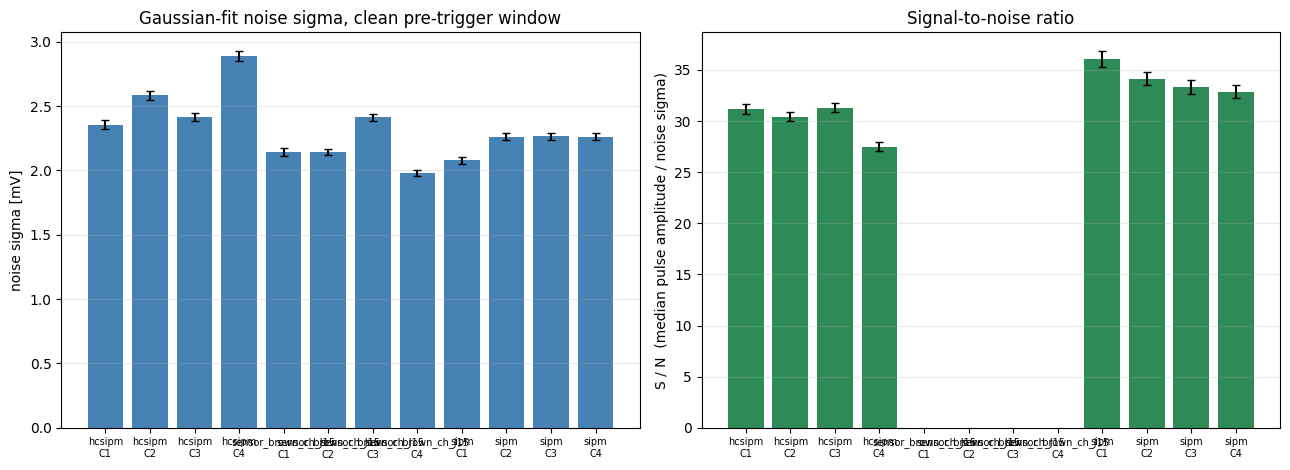

In [119]:
# NOISE TABLE: fitted noise sigma with uncertainty, and S/N ratio, per channel
if not noise_sigma_summary.empty:
    ordered = noise_sigma_summary.sort_values(["device", "channel"])
    labels = [f"{r.device}\n{r.channel}" for r in ordered.itertuples()]
    x = np.arange(len(ordered))
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].bar(x, ordered["noise_sigma_mv"], yerr=ordered["noise_sigma_unc_mv"],
               capsize=3, color="steelblue")
    axes[0].set_ylabel("noise sigma [mV]")
    axes[0].set_title("Gaussian-fit noise sigma, clean pre-trigger window")
    axes[1].bar(x, ordered["signal_to_noise"], yerr=ordered["signal_to_noise_unc"],
               capsize=3, color="seagreen")
    axes[1].set_ylabel("S / N  (median pulse amplitude / noise sigma)")
    axes[1].set_title("Signal-to-noise ratio")
    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels(labels, fontsize=7)
        axis.grid(alpha=0.25, axis="y")
    finish(figure, "bg13_noise_sigma_table")

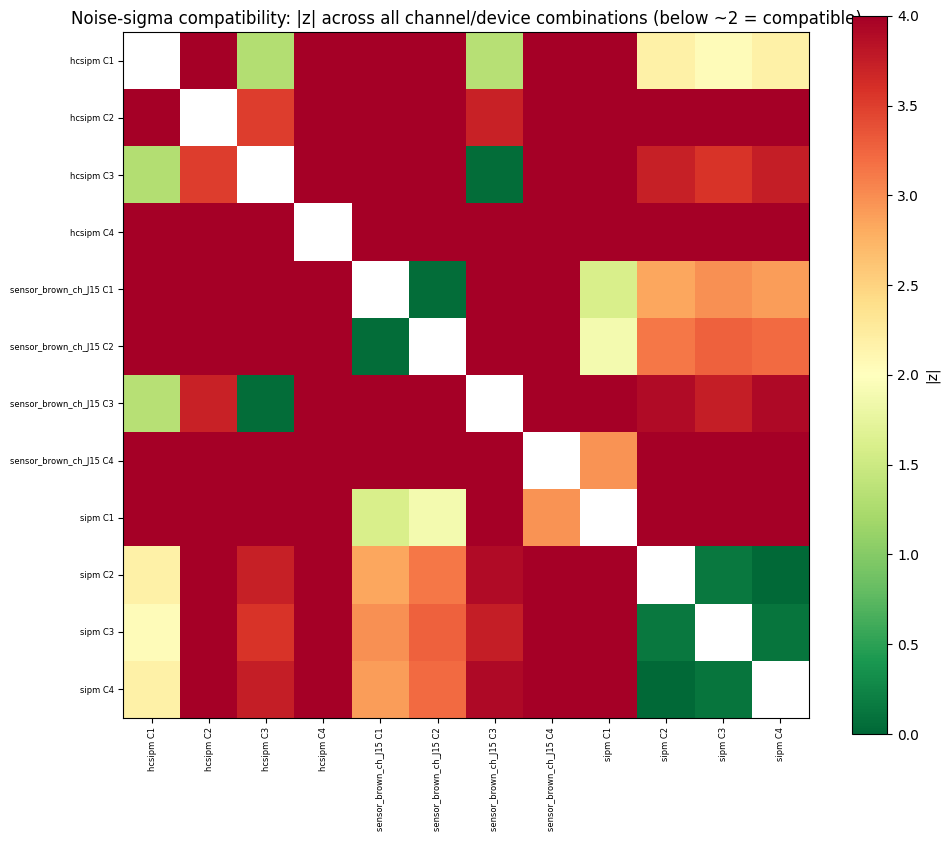

In [120]:
# NOISE-COMPAT: pairwise compatibility of the noise sigma across every channel/device combination
if not noise_sigma_compat.empty:
    sub = noise_sigma_compat.copy()
    sub["label_1"] = sub["device_1"] + " " + sub["channel_1"]
    sub["label_2"] = sub["device_2"] + " " + sub["channel_2"]
    labels = sorted(set(sub["label_1"]) | set(sub["label_2"]))
    n = len(labels)
    idx = {l: i for i, l in enumerate(labels)}
    matrix = np.full((n, n), np.nan)
    for r in sub.itertuples():
        i, j = idx[r.label_1], idx[r.label_2]
        matrix[i, j] = matrix[j, i] = abs(r.z_score)
    figure, axis = plt.subplots(figsize=(10, 8.5))
    image = axis.imshow(matrix, cmap="RdYlGn_r", vmin=0, vmax=4)
    axis.set_xticks(range(n)); axis.set_xticklabels(labels, fontsize=6, rotation=90)
    axis.set_yticks(range(n)); axis.set_yticklabels(labels, fontsize=6)
    axis.set_title("Noise-sigma compatibility: |z| across all channel/device combinations "
                   "(below ~2 = compatible)")
    figure.colorbar(image, ax=axis, label="|z|")
    finish(figure, "bg14_noise_sigma_compatibility")

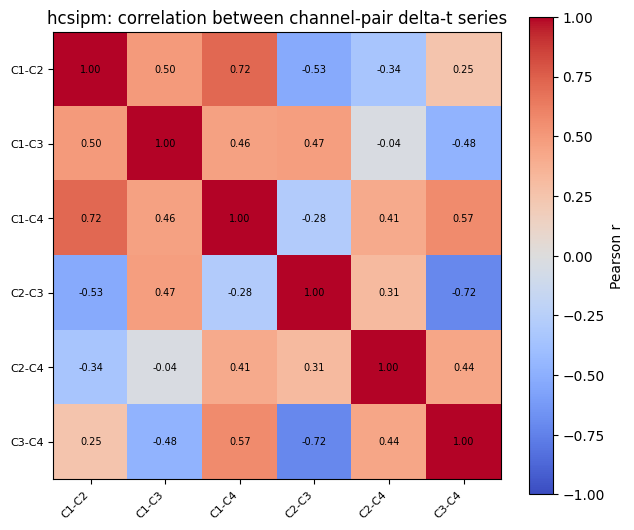

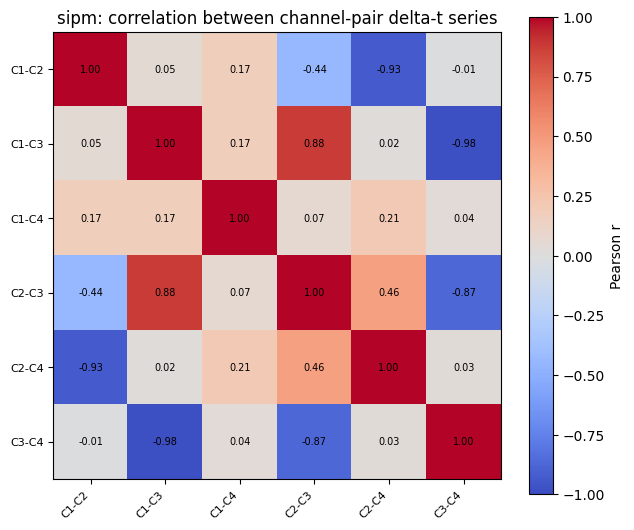

In [121]:
# CORR 1: correlation between channel-pair delta-t series (common-channel jitter check).
# Pairs sharing a channel (e.g. C1-C2 and C1-C3) are expected to correlate through that
# shared channel's jitter; pairs that share no channel (e.g. C1-C2 and C3-C4) should show
# ~0 correlation if the four channels really are independent.
if not delta_t_corr.empty:
    for run in sorted(delta_t_corr["coincidence_run"].unique()):
        sub = delta_t_corr[delta_t_corr["coincidence_run"] == run]
        labels = sorted(set(sub["pair_1"]) | set(sub["pair_2"]))
        n = len(labels)
        idx = {l: i for i, l in enumerate(labels)}
        matrix = np.full((n, n), np.nan)
        np.fill_diagonal(matrix, 1.0)
        for r in sub.itertuples():
            i, j = idx[r.pair_1], idx[r.pair_2]
            matrix[i, j] = matrix[j, i] = r.pearson_r
        figure, axis = plt.subplots(figsize=(6.5, 5.5))
        image = axis.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
        axis.set_xticks(range(n)); axis.set_xticklabels(labels, fontsize=8, rotation=45, ha="right")
        axis.set_yticks(range(n)); axis.set_yticklabels(labels, fontsize=8)
        for i in range(n):
            for j in range(n):
                if np.isfinite(matrix[i, j]):
                    axis.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=7)
        axis.set_title(f"{run}: correlation between channel-pair delta-t series")
        figure.colorbar(image, ax=axis, label="Pearson r")
        finish(figure, f"tm10_delta_t_correlation_{run}")

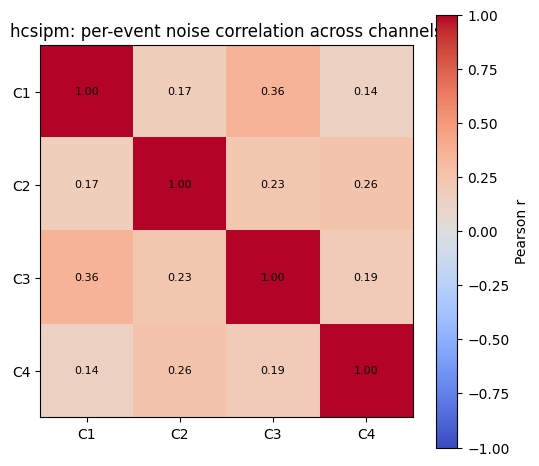

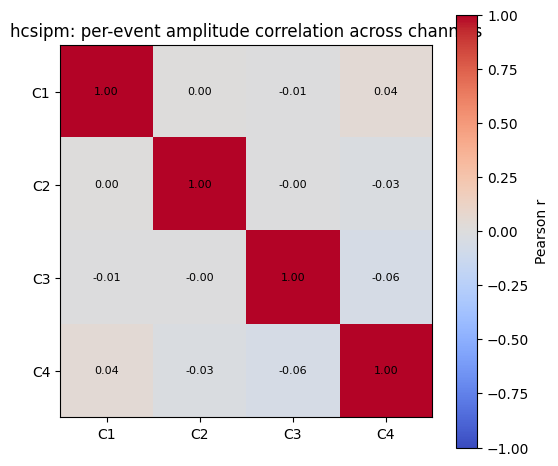

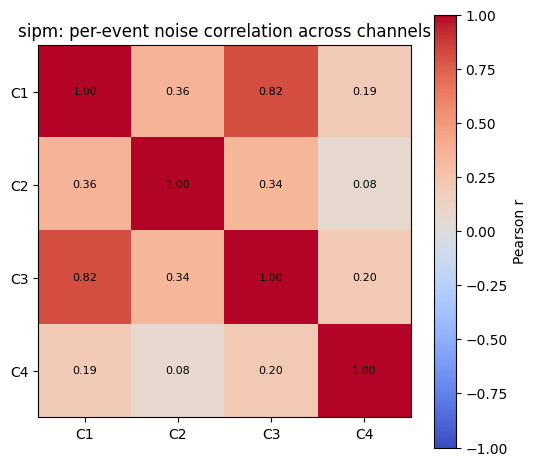

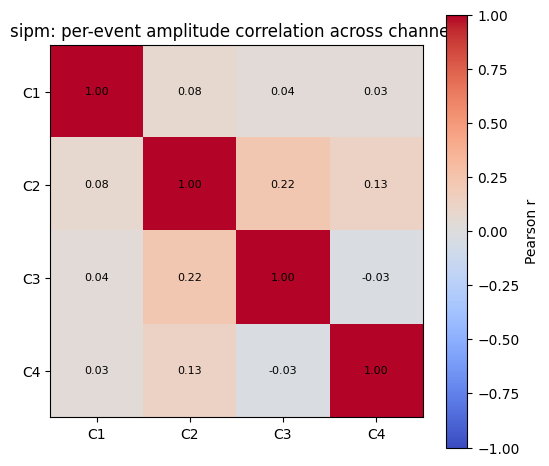

In [122]:
# CORR 2: correlation between channels' per-event noise / amplitude
if not channel_noise_corr.empty:
    for device in sorted(channel_noise_corr["device"].unique()):
        for quantity in ("noise", "amplitude"):
            sub = channel_noise_corr[(channel_noise_corr["device"] == device) &
                                     (channel_noise_corr["quantity"] == quantity)]
            if sub.empty:
                continue
            labels = list(CHANNELS)
            n = len(labels)
            idx = {l: i for i, l in enumerate(labels)}
            matrix = np.full((n, n), np.nan)
            np.fill_diagonal(matrix, 1.0)
            for r in sub.itertuples():
                if r.channel_a in idx and r.channel_b in idx:
                    i, j = idx[r.channel_a], idx[r.channel_b]
                    matrix[i, j] = matrix[j, i] = r.pearson_r
            figure, axis = plt.subplots(figsize=(5.5, 4.8))
            image = axis.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
            axis.set_xticks(range(n)); axis.set_xticklabels(labels)
            axis.set_yticks(range(n)); axis.set_yticklabels(labels)
            for i in range(n):
                for j in range(n):
                    if np.isfinite(matrix[i, j]):
                        axis.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)
            axis.set_title(f"{device}: per-event {quantity} correlation across channels")
            figure.colorbar(image, ax=axis, label="Pearson r")
            finish(figure, f"tm11_{quantity}_correlation_{device}")